In [3]:
# =============================================================================
# CELL 1: IMPORTS AND SETUP
# =============================================================================
import pandas as pd
import numpy as np
import pyodbc
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 50)

def run_sql(query):
    with pyodbc.connect("DSN=Redshift_prod_new") as conn:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=conn)
        warnings.filterwarnings("default", category=UserWarning)
    return df

with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    conn.cursor().execute("SELECT 1").fetchone()
print("ODBC connection OK")

ODBC connection OK


In [4]:
# =============================================================================
# CELL 2: FETCH INDIVIDUAL RAGU INPUTS
# =============================================================================

ragu_df = run_sql("""
    SELECT r.account_number, r.lob, r.book_date,
           r.model_score, r.gross_loss_impact, r.gross_loss_ragu,
           r.ltv, r.apr, r.amt_financed, r.recovery_multiplier
    FROM sandbox.gl_ragu_individual r
    WHERE r.gross_loss_ragu IS NOT NULL
""")

ragu_df['book_date'] = pd.to_datetime(ragu_df['book_date'])
print(f"RAGU rows: {len(ragu_df):,}")
print(f"\nLOB distribution:")
print(ragu_df['lob'].value_counts())

print("\n--- model_score range by LOB ---")
print(ragu_df.groupby('lob')['model_score'].describe(
    percentiles=[0.25, 0.5, 0.75]
)[['min', '25%', '50%', '75%', 'max']].round(2))

print("\n--- gross_loss_impact range by LOB ---")
print(ragu_df.groupby('lob')['gross_loss_impact'].describe(
    percentiles=[0.25, 0.5, 0.75]
)[['min', '25%', '50%', '75%', 'max']].round(4))

RAGU rows: 818,180

LOB distribution:
lob
KMX    429414
FRN    116750
ENT    101365
STG     88248
AN      49442
FLD     32961
Name: count, dtype: int64

--- model_score range by LOB ---
       min    25%    50%    75%    max
lob                                   
AN   103.0  132.0  136.0  142.0  191.0
ENT  103.0  130.0  134.0  138.0  189.0
FLD  107.0  133.0  138.0  143.0  197.0
FRN  100.0  134.0  139.0  144.0  202.0
KMX   90.0  132.0  138.0  144.0  227.0
STG   96.0  132.0  137.0  142.0  202.0

--- gross_loss_impact range by LOB ---
      min     25%     50%     75%   max
lob                                    
AN  -10.0 -1.0409  2.2676  4.6901   7.5
ENT -10.0 -2.9597  0.6872  2.3558   7.5
FLD -10.0 -1.7440  2.3558  5.0000   7.5
FRN -10.0 -1.7788  1.9029  4.4529   7.5
KMX -20.0 -0.7319  2.9732  5.4655  10.0
STG -10.0 -1.0409  2.2676  4.7487   7.5


In [5]:
# =============================================================================
# CELL 2b: FETCH CONTRACT TERM FOR V2 UNIT-LOSS COMPUTATION
# =============================================================================

term_df = run_sql("""
    SELECT account_number,
           con_term
    FROM edwnpi.los_deal_current_fact
    WHERE con_term IS NOT NULL
""")

print(f"Term rows: {len(term_df):,}")
print(f"\n--- con_term distribution ---")
print(term_df['con_term'].describe().round(1))

Term rows: 1,582,753

--- con_term distribution ---
count    1582753.0
mean          67.0
std           13.7
min            0.0
25%           66.0
50%           72.0
75%           72.0
max          720.0
Name: con_term, dtype: float64


In [6]:
# =============================================================================
# CELL 3: FETCH ACTUAL CHARGEOFF OUTCOMES
# =============================================================================

actuals_df = run_sql("""
    WITH all_accounts AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(proceeds) AS proceeds
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
        GROUP BY 1, 2
    ),
    chargeoffs AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(gross_loss_amt) AS gross_loss_amt,
               MAX(net_loss_amt) AS net_loss_amt
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
          AND account_life_cycle = 'CHARGEOFF'
        GROUP BY 1, 2
    )
    SELECT a.account_number,
           a.sp_book_date_quarter_vintage AS vintage,
           a.proceeds,
           COALESCE(co.gross_loss_amt, 0) AS gross_loss_amt,
           COALESCE(co.net_loss_amt, 0) AS net_loss_amt,
           CASE WHEN co.account_number IS NOT NULL THEN 1 ELSE 0 END AS is_chargeoff
    FROM all_accounts a
    LEFT JOIN chargeoffs co
        ON a.account_number = co.account_number
       AND a.sp_book_date_quarter_vintage = co.sp_book_date_quarter_vintage
""")

print(f"Actuals rows: {len(actuals_df):,}")
print(f"Chargeoff rate: {actuals_df['is_chargeoff'].mean():.4f}")
print(f"Vintages: {actuals_df['vintage'].nunique()}")
print(f"Vintage range: {actuals_df['vintage'].min()} to {actuals_df['vintage'].max()}")

Actuals rows: 929,442
Chargeoff rate: 0.3432
Vintages: 27
Vintage range: 2020 Q1 to 225 Q4


In [7]:
# =============================================================================
# CELL 4: MERGE, FILTER, COMPUTE V1 / V2 PREDICTIONS
# =============================================================================

# --- V1 / V2 constants ---
V1_UL = 0.5
V1_UL_TO_MS = 0.02
V2_UL_TO_MS = 0.027

BASELINES = {
    'AN':  {'ltv': 1.94, 'apr': 0.25},
    'FRN': {'ltv': 1.94, 'apr': 0.25},
    'STG': {'ltv': 1.94, 'apr': 0.25},
    'FLD': {'ltv': 1.45, 'apr': 0.235},
    'ENT': {'ltv': 1.45, 'apr': 0.235},
    'KMX': {'ltv': 1.59, 'apr': 0.25},
}

MATURITY_CUTOFF = '2023-12-31'

# --- Merge RAGU inputs with term data ---
ragu_with_term = ragu_df.merge(
    term_df[['account_number', 'con_term']].drop_duplicates(subset='account_number', keep='first'),
    on='account_number', how='left'
)
print(f"RAGU rows with term data: {ragu_with_term['con_term'].notna().sum():,} / {len(ragu_with_term):,}")

# --- Merge with actuals ---
merged = ragu_with_term.merge(
    actuals_df[['account_number', 'vintage', 'proceeds', 'gross_loss_amt',
                'net_loss_amt', 'is_chargeoff']],
    on='account_number', how='inner'
)
print(f"\nPre-filter merged rows: {len(merged):,}")
print(f"Book date range: {merged['book_date'].min()} to {merged['book_date'].max()}")

# --- Maturity filter ---
merged = merged[merged['book_date'] <= MATURITY_CUTOFF].copy()
print(f"\nAfter maturity filter (<= {MATURITY_CUTOFF}): {len(merged):,} rows")
print(f"  Chargeoffs: {merged['is_chargeoff'].sum():,} ({merged['is_chargeoff'].mean():.1%})")
print(f"  con_term coverage: {merged['con_term'].notna().sum():,} ({merged['con_term'].notna().mean():.1%})")

# --- Actual gross loss metrics ---
merged['gross_loss_pct'] = merged['gross_loss_amt'] / merged['proceeds']
merged['cnl_pct'] = merged['net_loss_amt'] / merged['proceeds']

# --- Back-derive loss_multiplier from V1 formula ---
# V1: gross_loss_impact = (1 - loss_multiplier) * V1_UL / V1_UL_TO_MS
# => loss_multiplier = 1 - gross_loss_impact * V1_UL_TO_MS / V1_UL
merged['loss_multiplier'] = 1 - merged['gross_loss_impact'] * V1_UL_TO_MS / V1_UL

# --- APR impact (same formula for both V1 and V2) ---
merged['baseline_apr'] = merged['lob'].map({k: v['apr'] for k, v in BASELINES.items()})
merged['apr_mult'] = np.where(merged['lob'] == 'KMX', 0.7 / 0.65, 0.7)
merged['apr_impact'] = (merged['baseline_apr'] - merged['apr']) / 0.01 * merged['apr_mult']

# --- V1 gross-loss predicted score ---
# gl_predicted_v1 = model_score + gross_loss_impact (already V1) + apr_impact
merged['gl_predicted_v1'] = merged['model_score'] + merged['gross_loss_impact'] + merged['apr_impact']

# --- V2 gross-loss predicted score ---
# V2 unit_loss = 0.9 - (model_score - 125) * 0.027 - (72 - con_term) / 240
merged['con_term_filled'] = merged['con_term'].fillna(72)
merged['unit_loss_v2'] = 0.9 - (merged['model_score'] - 125) * V2_UL_TO_MS - (72 - merged['con_term_filled']) / 240
merged['gl_impact_v2'] = (1 - merged['loss_multiplier']) * merged['unit_loss_v2'] / V2_UL_TO_MS
merged['gl_predicted_v2'] = merged['model_score'] + merged['gl_impact_v2'] + merged['apr_impact']

# --- Summary stats ---
print(f"\n--- Summary stats (all loans) ---")
for col in ['model_score', 'loss_multiplier', 'apr', 'gross_loss_impact',
            'gl_predicted_v1', 'gl_predicted_v2', 'gross_loss_pct']:
    vals = merged[col].dropna()
    print(f"  {col:>25s}: mean={vals.mean():.4f}  median={vals.median():.4f}  std={vals.std():.4f}")

print(f"\n--- Chargeoff population ---")
co = merged[merged['is_chargeoff'] == 1].copy()
print(f"Chargeoffs: {len(co):,}")
print(f"  mean gross_loss_pct: {co['gross_loss_pct'].mean():.4f}")
print(f"  mean model_score:    {co['model_score'].mean():.2f}")
print(f"  mean loss_multiplier:{co['loss_multiplier'].mean():.4f}")
print(f"  mean apr:            {co['apr'].mean():.4f}")

print(f"\n--- LOB breakdown (chargeoffs) ---")
print(co['lob'].value_counts().sort_index())

RAGU rows with term data: 818,179 / 818,180

Pre-filter merged rows: 805,967
Book date range: 2020-01-02 00:00:00 to 2026-06-30 00:00:00

After maturity filter (<= 2023-12-31): 449,826 rows
  Chargeoffs: 228,422 (50.8%)
  con_term coverage: 449,826 (100.0%)

--- Summary stats (all loans) ---
                model_score: mean=135.9920  median=135.0000  std=9.8081
            loss_multiplier: mean=0.9366  median=0.9058  std=0.1864
                        apr: mean=0.2490  median=0.2500  std=0.0327
          gross_loss_impact: mean=1.5851  median=2.3558  std=4.6590
            gl_predicted_v1: mean=137.4791  median=136.2175  std=12.8789
            gl_predicted_v2: mean=136.9573  median=136.4838  std=11.9133
             gross_loss_pct: mean=0.4174  median=0.0368  std=0.4475

--- Chargeoff population ---
Chargeoffs: 228,422
  mean gross_loss_pct: 0.8221
  mean model_score:    133.37
  mean loss_multiplier:0.9598
  mean apr:            0.2529

--- LOB breakdown (chargeoffs) ---
lob
AN     

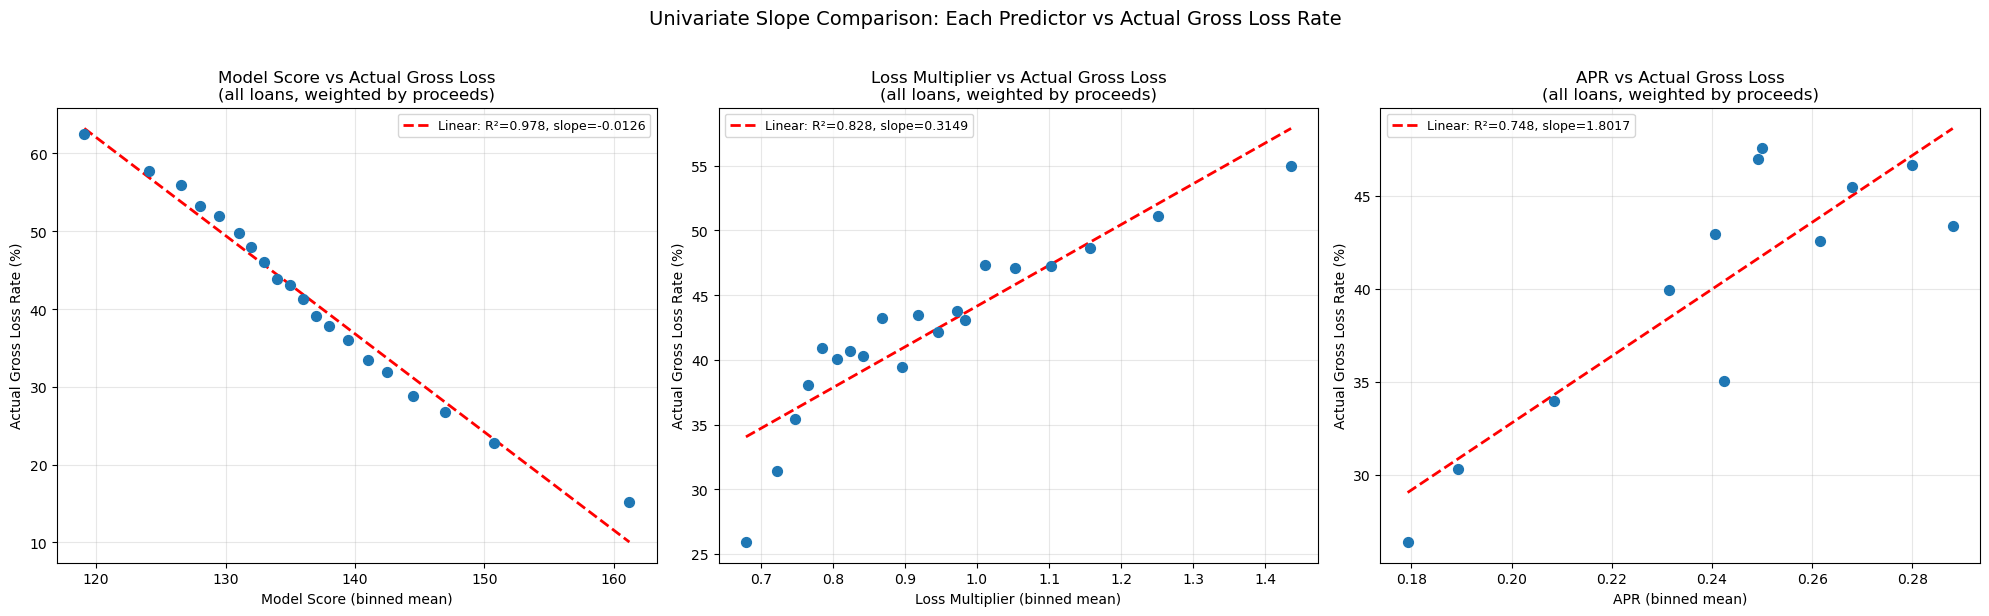

UNIVARIATE SLOPE COMPARISON (all loans, weighted by proceeds)

Predictor                             Slope    Intercept       R²   N bins
---------------------------------------------------------------------------
Model Score                       -0.012624    +2.135568    0.978       20
Loss Multiplier                   +0.314932    +0.126539    0.828       20
APR                               +1.801747    -0.032638    0.748       12


In [8]:
# =============================================================================
# CELL 5: UNIVARIATE SLOPE COMPARISON
# =============================================================================

N_BINS = 20

# --- Model Score vs actual gross loss rate (all loans) ---
merged['ms_band'] = pd.qcut(merged['model_score'], q=N_BINS, duplicates='drop')
ms_agg = merged.groupby('ms_band', observed=True).agg(
    ms_mid=('model_score', 'mean'),
    gl_rate=('gross_loss_pct', 'mean'),
    co_rate=('is_chargeoff', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
ms_agg['weighted_gl_rate'] = ms_agg['total_gl'] / ms_agg['total_proceeds']

slope_ms, intercept_ms, r_ms, _, _ = linregress(ms_agg['ms_mid'], ms_agg['weighted_gl_rate'])

# --- Loss Multiplier vs actual gross loss rate (all loans) ---
merged['lm_band'] = pd.qcut(merged['loss_multiplier'], q=N_BINS, duplicates='drop')
lm_agg = merged.groupby('lm_band', observed=True).agg(
    lm_mid=('loss_multiplier', 'mean'),
    gl_rate=('gross_loss_pct', 'mean'),
    co_rate=('is_chargeoff', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
lm_agg['weighted_gl_rate'] = lm_agg['total_gl'] / lm_agg['total_proceeds']

slope_lm, intercept_lm, r_lm, _, _ = linregress(lm_agg['lm_mid'], lm_agg['weighted_gl_rate'])

# --- APR vs actual gross loss rate (all loans) ---
merged['apr_band'] = pd.qcut(merged['apr'], q=N_BINS, duplicates='drop')
apr_agg = merged.groupby('apr_band', observed=True).agg(
    apr_mid=('apr', 'mean'),
    gl_rate=('gross_loss_pct', 'mean'),
    co_rate=('is_chargeoff', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
apr_agg['weighted_gl_rate'] = apr_agg['total_gl'] / apr_agg['total_proceeds']

slope_apr, intercept_apr, r_apr, _, _ = linregress(apr_agg['apr_mid'], apr_agg['weighted_gl_rate'])

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
ax.scatter(ms_agg['ms_mid'], ms_agg['weighted_gl_rate'] * 100, s=50, zorder=3)
x_fit = np.linspace(ms_agg['ms_mid'].min(), ms_agg['ms_mid'].max(), 100)
ax.plot(x_fit, (intercept_ms + slope_ms * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_ms**2:.3f}, slope={slope_ms:.4f}")
ax.set_xlabel('Model Score (binned mean)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title('Model Score vs Actual Gross Loss\n(all loans, weighted by proceeds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(lm_agg['lm_mid'], lm_agg['weighted_gl_rate'] * 100, s=50, zorder=3)
x_fit = np.linspace(lm_agg['lm_mid'].min(), lm_agg['lm_mid'].max(), 100)
ax.plot(x_fit, (intercept_lm + slope_lm * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_lm**2:.3f}, slope={slope_lm:.4f}")
ax.set_xlabel('Loss Multiplier (binned mean)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title('Loss Multiplier vs Actual Gross Loss\n(all loans, weighted by proceeds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(apr_agg['apr_mid'], apr_agg['weighted_gl_rate'] * 100, s=50, zorder=3)
x_fit = np.linspace(apr_agg['apr_mid'].min(), apr_agg['apr_mid'].max(), 100)
ax.plot(x_fit, (intercept_apr + slope_apr * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_apr**2:.3f}, slope={slope_apr:.4f}")
ax.set_xlabel('APR (binned mean)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title('APR vs Actual Gross Loss\n(all loans, weighted by proceeds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Univariate Slope Comparison: Each Predictor vs Actual Gross Loss Rate',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('gl_univariate_slopes.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("UNIVARIATE SLOPE COMPARISON (all loans, weighted by proceeds)")
print("=" * 80)
print(f"\n{'Predictor':<30} {'Slope':>12} {'Intercept':>12} {'R²':>8} {'N bins':>8}")
print("-" * 75)
print(f"{'Model Score':<30} {slope_ms:>+12.6f} {intercept_ms:>+12.6f} {r_ms**2:>8.3f} {len(ms_agg):>8}")
print(f"{'Loss Multiplier':<30} {slope_lm:>+12.6f} {intercept_lm:>+12.6f} {r_lm**2:>8.3f} {len(lm_agg):>8}")
print(f"{'APR':<30} {slope_apr:>+12.6f} {intercept_apr:>+12.6f} {r_apr**2:>8.3f} {len(apr_agg):>8}")

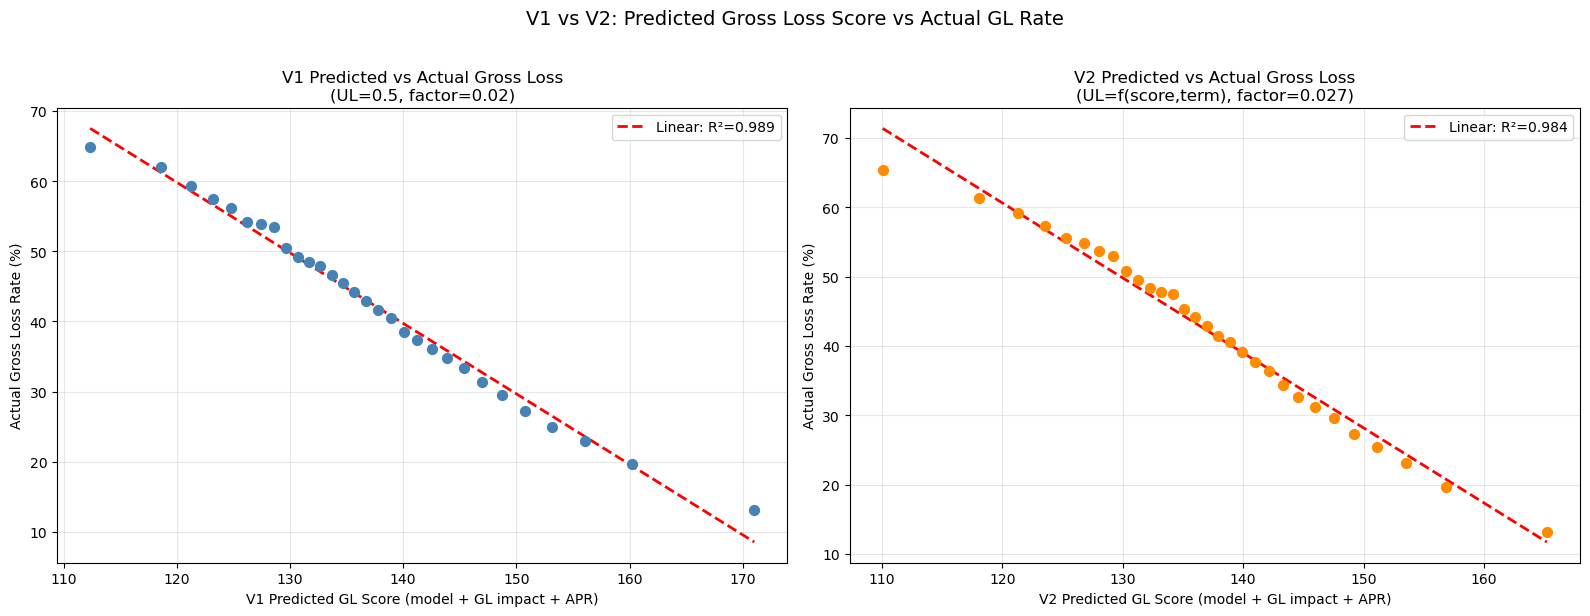

V1 vs V2 HEAD-TO-HEAD COMPARISON

Version                Slope    Intercept       R²   RMSE (bps)   N bins
----------------------------------------------------------------------
V1                 -0.010053    +1.804645    0.989        138.0       30
V2                 -0.010808    +1.902965    0.984        163.5       30

  >> V1 has higher binned R² (0.989 vs 0.984)


In [9]:
# =============================================================================
# CELL 6: V1 vs V2 HEAD-TO-HEAD COMPARISON
# =============================================================================

N_BINS_H2H = 30

# --- Bin by V1 predicted score ---
merged['v1_band'] = pd.qcut(merged['gl_predicted_v1'], q=N_BINS_H2H, duplicates='drop')
v1_agg = merged.groupby('v1_band', observed=True).agg(
    pred_mid=('gl_predicted_v1', 'mean'),
    gl_rate=('gross_loss_pct', 'mean'),
    co_rate=('is_chargeoff', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
v1_agg['weighted_gl_rate'] = v1_agg['total_gl'] / v1_agg['total_proceeds']

slope_v1, intercept_v1, r_v1, _, _ = linregress(v1_agg['pred_mid'], v1_agg['weighted_gl_rate'])

# --- Bin by V2 predicted score ---
merged['v2_band'] = pd.qcut(merged['gl_predicted_v2'], q=N_BINS_H2H, duplicates='drop')
v2_agg = merged.groupby('v2_band', observed=True).agg(
    pred_mid=('gl_predicted_v2', 'mean'),
    gl_rate=('gross_loss_pct', 'mean'),
    co_rate=('is_chargeoff', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
v2_agg['weighted_gl_rate'] = v2_agg['total_gl'] / v2_agg['total_proceeds']

slope_v2, intercept_v2, r_v2, _, _ = linregress(v2_agg['pred_mid'], v2_agg['weighted_gl_rate'])

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(v1_agg['pred_mid'], v1_agg['weighted_gl_rate'] * 100, s=50, zorder=3, color='steelblue')
x_fit = np.linspace(v1_agg['pred_mid'].min(), v1_agg['pred_mid'].max(), 100)
ax.plot(x_fit, (intercept_v1 + slope_v1 * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_v1**2:.3f}")
ax.set_xlabel('V1 Predicted GL Score (model + GL impact + APR)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'V1 Predicted vs Actual Gross Loss\n(UL={V1_UL}, factor={V1_UL_TO_MS})')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(v2_agg['pred_mid'], v2_agg['weighted_gl_rate'] * 100, s=50, zorder=3, color='darkorange')
x_fit = np.linspace(v2_agg['pred_mid'].min(), v2_agg['pred_mid'].max(), 100)
ax.plot(x_fit, (intercept_v2 + slope_v2 * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_v2**2:.3f}")
ax.set_xlabel('V2 Predicted GL Score (model + GL impact + APR)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'V2 Predicted vs Actual Gross Loss\n(UL=f(score,term), factor={V2_UL_TO_MS})')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('V1 vs V2: Predicted Gross Loss Score vs Actual GL Rate',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('gl_v1_vs_v2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Residual analysis ---
v1_resid = v1_agg['weighted_gl_rate'] - (intercept_v1 + slope_v1 * v1_agg['pred_mid'])
v2_resid = v2_agg['weighted_gl_rate'] - (intercept_v2 + slope_v2 * v2_agg['pred_mid'])

print("=" * 80)
print("V1 vs V2 HEAD-TO-HEAD COMPARISON")
print("=" * 80)
print(f"\n{'Version':<15} {'Slope':>12} {'Intercept':>12} {'R²':>8} {'RMSE (bps)':>12} {'N bins':>8}")
print("-" * 70)
print(f"{'V1':<15} {slope_v1:>+12.6f} {intercept_v1:>+12.6f} {r_v1**2:>8.3f} "
      f"{np.sqrt((v1_resid**2).mean()) * 10000:>12.1f} {len(v1_agg):>8}")
print(f"{'V2':<15} {slope_v2:>+12.6f} {intercept_v2:>+12.6f} {r_v2**2:>8.3f} "
      f"{np.sqrt((v2_resid**2).mean()) * 10000:>12.1f} {len(v2_agg):>8}")

winner = "V2" if r_v2**2 > r_v1**2 else "V1"
print(f"\n  >> {winner} has higher binned R² ({max(r_v1**2, r_v2**2):.3f} vs {min(r_v1**2, r_v2**2):.3f})")

In [10]:
# =============================================================================
# CELL 7: LOAN-LEVEL OLS REGRESSIONS
# =============================================================================

# Use all loans (not just chargeoffs) -- gross_loss_pct = 0 for non-chargeoffs
valid = merged[
    merged['model_score'].notna() &
    merged['loss_multiplier'].notna() &
    merged['apr'].notna() &
    merged['gross_loss_pct'].notna()
].copy()

y = valid['gross_loss_pct'].values

# V1 gross-loss impact as a single feature (V1 weighting)
valid['gl_impact_v1'] = (1 - valid['loss_multiplier']) * V1_UL / V1_UL_TO_MS

# V2 gross-loss impact (already computed)
# valid['gl_impact_v2'] already exists

# Interaction term
valid['ms_x_lm'] = valid['model_score'] * valid['loss_multiplier']

# --- Model specifications ---
specs = {
    'M1: model_score only':              valid[['model_score']].values,
    'M2: model_score + LM (raw)':        valid[['model_score', 'loss_multiplier']].values,
    'M3: V1 composite (ms + gl_v1)':     valid[['model_score', 'gl_impact_v1']].values,
    'M4: V2 composite (ms + gl_v2)':     valid[['model_score', 'gl_impact_v2']].values,
    'M5: ms + LM + APR (raw inputs)':    valid[['model_score', 'loss_multiplier', 'apr']].values,
    'M6: V1 full (ms + gl_v1 + apr)':    valid[['model_score', 'gl_impact_v1', 'apr_impact']].values,
    'M7: V2 full (ms + gl_v2 + apr)':    valid[['model_score', 'gl_impact_v2', 'apr_impact']].values,
    'M8: ms + LM + APR + ms*LM':        valid[['model_score', 'loss_multiplier', 'apr', 'ms_x_lm']].values,
    'M9: OLS-optimal (ms, LM, APR)':    valid[['model_score', 'loss_multiplier', 'apr']].values,
}

spec_labels = {
    'M1: model_score only':              ['ms'],
    'M2: model_score + LM (raw)':        ['ms', 'LM'],
    'M3: V1 composite (ms + gl_v1)':     ['ms', 'gl_v1'],
    'M4: V2 composite (ms + gl_v2)':     ['ms', 'gl_v2'],
    'M5: ms + LM + APR (raw inputs)':    ['ms', 'LM', 'APR'],
    'M6: V1 full (ms + gl_v1 + apr)':    ['ms', 'gl_v1', 'apr_i'],
    'M7: V2 full (ms + gl_v2 + apr)':    ['ms', 'gl_v2', 'apr_i'],
    'M8: ms + LM + APR + ms*LM':        ['ms', 'LM', 'APR', 'ms*LM'],
    'M9: OLS-optimal (ms, LM, APR)':    ['ms', 'LM', 'APR'],
}

print("=" * 110)
print("LOAN-LEVEL REGRESSIONS: Actual Gross Loss Rate ~ Predictors")
print(f"Population: {len(valid):,} loans with complete data")
print("=" * 110)
print(f"\n{'Model':<38} {'R²':>8} {'Adj R²':>8}  Coefficients")
print("-" * 110)

models = {}
for name, X in specs.items():
    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)
    r2 = r2_score(y, y_pred)
    n, k = len(y), X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    models[name] = {'model': lr, 'r2': r2, 'adj_r2': adj_r2}

    coef_str = f"intercept={lr.intercept_:.6f}"
    for lbl, c in zip(spec_labels[name], lr.coef_):
        coef_str += f", {lbl}={c:.6f}"

    print(f"{name:<38} {r2:>8.5f} {adj_r2:>8.5f}  {coef_str}")

# --- Binned regressions (for comparison with aggregated-data R-squared) ---
N_REG_BINS = 25
print(f"\n{'=' * 110}")
print(f"BINNED REGRESSIONS (N={N_REG_BINS} equal-frequency bins)")
print(f"{'=' * 110}")
print(f"\n{'Model':<38} {'Binned R²':>10} {'N bins':>8}")
print("-" * 60)

for name in ['M5: ms + LM + APR (raw inputs)', 'M6: V1 full (ms + gl_v1 + apr)',
             'M7: V2 full (ms + gl_v2 + apr)', 'M9: OLS-optimal (ms, LM, APR)']:
    lr_model = models[name]['model']
    valid[f'pred_{name[:2]}'] = lr_model.predict(specs[name])
    col = f'pred_{name[:2]}'
    valid['_bin'] = pd.qcut(valid[col], q=N_REG_BINS, duplicates='drop')
    binned = valid.groupby('_bin', observed=True).agg(
        pred_mid=(col, 'mean'),
        actual=('gross_loss_pct', 'mean'),
    ).dropna()
    if len(binned) >= 3:
        _, _, r_b, _, _ = linregress(binned['pred_mid'], binned['actual'])
        print(f"{name:<38} {r_b**2:>10.3f} {len(binned):>8}")
    valid.drop(columns='_bin', inplace=True)

LOAN-LEVEL REGRESSIONS: Actual Gross Loss Rate ~ Predictors
Population: 449,826 loans with complete data

Model                                        R²   Adj R²  Coefficients
--------------------------------------------------------------------------------------------------------------
M1: model_score only                    0.07450  0.07450  intercept=2.110995, ms=-0.012453
M2: model_score + LM (raw)              0.08133  0.08133  intercept=1.823393, ms=-0.011730, LM=0.202094
M3: V1 composite (ms + gl_v1)           0.08133  0.08133  intercept=2.025486, ms=-0.011730, gl_v1=-0.008084
M4: V2 composite (ms + gl_v2)           0.08063  0.08062  intercept=2.130166, ms=-0.012533, gl_v2=-0.007886
M5: ms + LM + APR (raw inputs)          0.08550  0.08549  intercept=1.528193, ms=-0.011102, LM=0.183337, APR=0.912981
M6: V1 full (ms + gl_v1 + apr)          0.08457  0.08457  intercept=1.938670, ms=-0.011108, gl_v1=-0.007222, apr_i=-0.008623
M7: V2 full (ms + gl_v2 + apr)          0.08431  0.08430  

INCREMENTAL R² ATTRIBUTION: How much does each component add?

Step                                        R²        ΔR²     Adj R²
----------------------------------------------------------------------
  model_score alone                    0.07450   +0.07450    0.07450
  + loss_multiplier                    0.08133   +0.00683    0.08133
  + APR                                0.08550   +0.00417    0.08549
  + interaction (ms*LM)                0.08564   +0.00014    0.08563

CONVERSION FACTOR COMPARISON: Does the factor matter?

    Factor    R² (with const UL=0.5)      R² (with V2 UL)
------------------------------------------------------------
     0.015           0.08457                0.08431        
     0.018           0.08457                0.08431        
     0.020           0.08457  <-- V1        0.08431        
     0.022           0.08457                0.08431        
     0.025           0.08457                0.08431        
     0.027           0.08457                0.

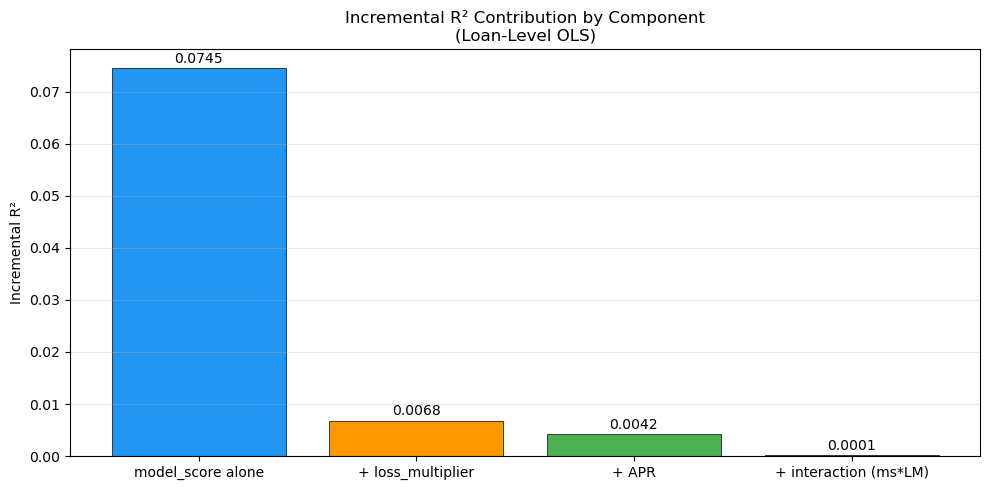

In [11]:
# =============================================================================
# CELL 8: INCREMENTAL R-SQUARED ATTRIBUTION BY COMPONENT
# =============================================================================

print("=" * 90)
print("INCREMENTAL R² ATTRIBUTION: How much does each component add?")
print("=" * 90)

# --- Stepwise: model_score -> + loss_multiplier -> + APR ---
steps_raw = [
    ('model_score alone',       ['model_score']),
    ('+ loss_multiplier',       ['model_score', 'loss_multiplier']),
    ('+ APR',                   ['model_score', 'loss_multiplier', 'apr']),
    ('+ interaction (ms*LM)',   ['model_score', 'loss_multiplier', 'apr', 'ms_x_lm']),
]

print(f"\n{'Step':<35} {'R²':>10} {'ΔR²':>10} {'Adj R²':>10}")
print("-" * 70)

prev_r2 = 0
for label, cols in steps_raw:
    X = valid[cols].values
    lr = LinearRegression().fit(X, y)
    r2 = r2_score(y, lr.predict(X))
    n, k = len(y), X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    delta = r2 - prev_r2
    print(f"  {label:<33} {r2:>10.5f} {delta:>+10.5f} {adj_r2:>10.5f}")
    prev_r2 = r2

# --- V1 vs V2 conversion factor comparison ---
print(f"\n{'=' * 90}")
print("CONVERSION FACTOR COMPARISON: Does the factor matter?")
print("=" * 90)

factors = [0.015, 0.018, 0.020, 0.022, 0.025, 0.027, 0.030, 0.035]
print(f"\n{'Factor':>10} {'R² (with const UL=0.5)':>25} {'R² (with V2 UL)':>20}")
print("-" * 60)

for factor in factors:
    # Constant UL version
    valid['_gl_const'] = (1 - valid['loss_multiplier']) * V1_UL / factor
    X_const = valid[['model_score', '_gl_const', 'apr_impact']].values
    r2_const = r2_score(y, LinearRegression().fit(X_const, y).predict(X_const))

    # V2-style UL version
    valid['_gl_v2'] = (1 - valid['loss_multiplier']) * valid['unit_loss_v2'] / factor
    X_v2 = valid[['model_score', '_gl_v2', 'apr_impact']].values
    r2_v2 = r2_score(y, LinearRegression().fit(X_v2, y).predict(X_v2))

    marker_const = " <-- V1" if factor == V1_UL_TO_MS else ""
    marker_v2 = " <-- V2" if factor == V2_UL_TO_MS else ""
    print(f"  {factor:>8.3f}   {r2_const:>15.5f}{marker_const:>8}   {r2_v2:>12.5f}{marker_v2:>8}")

valid.drop(columns=['_gl_const', '_gl_v2'], inplace=True)

# --- Bar chart of incremental R-squared ---
step_labels = [s[0] for s in steps_raw]
r2_values = []
prev_r2 = 0
for label, cols in steps_raw:
    X = valid[cols].values
    r2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
    r2_values.append(r2 - prev_r2)
    prev_r2 = r2

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
bars = ax.bar(step_labels, r2_values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Incremental R²')
ax.set_title('Incremental R² Contribution by Component\n(Loan-Level OLS)')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('gl_incremental_r2.png', dpi=150, bbox_inches='tight')
plt.show()

GROSS LOSS RATE (%) = Gross Loss / Proceeds  --  ALL LOANS
Rows: Model Score bands | Columns: Loss Multiplier quintiles


lm_quintile,Q1 (Low),Q2,Q3,Q4,Q5 (High)
ms_band_fixed,,,,,
120-125,53.94,58.27,58.79,60.38,63.88
125-130,48.87,53.02,53.89,54.76,60.28
130-135,41.85,45.58,47.01,48.19,53.25
135-140,34.88,38.99,38.63,41.81,46.57
140-145,27.66,31.76,32.67,35.14,40.33
145-150,22.87,26.36,27.51,28.29,34.39
150-155,19.99,20.12,21.87,23.78,28.79
155-160,14.87,17.55,17.74,19.20,21.23
160-165,12.46,15.41,13.60,14.37,14.61



LOAN COUNT  --  ALL LOANS
Rows: Model Score bands | Columns: Loss Multiplier quintiles


lm_quintile,Q1 (Low),Q2,Q3,Q4,Q5 (High)
ms_band_fixed,,,,,
120-125,3189,6504,6303,7752,7300
125-130,7559,13490,14219,17640,16876
130-135,14288,20377,22493,23779,23399
135-140,20934,18307,19760,17339,17212
140-145,18187,13238,12714,10700,10540
145-150,11429,7922,6868,5492,5580
150-155,6386,4044,3434,2625,2365
155-160,3246,1989,1596,1194,1099
160-165,1748,1036,797,554,458


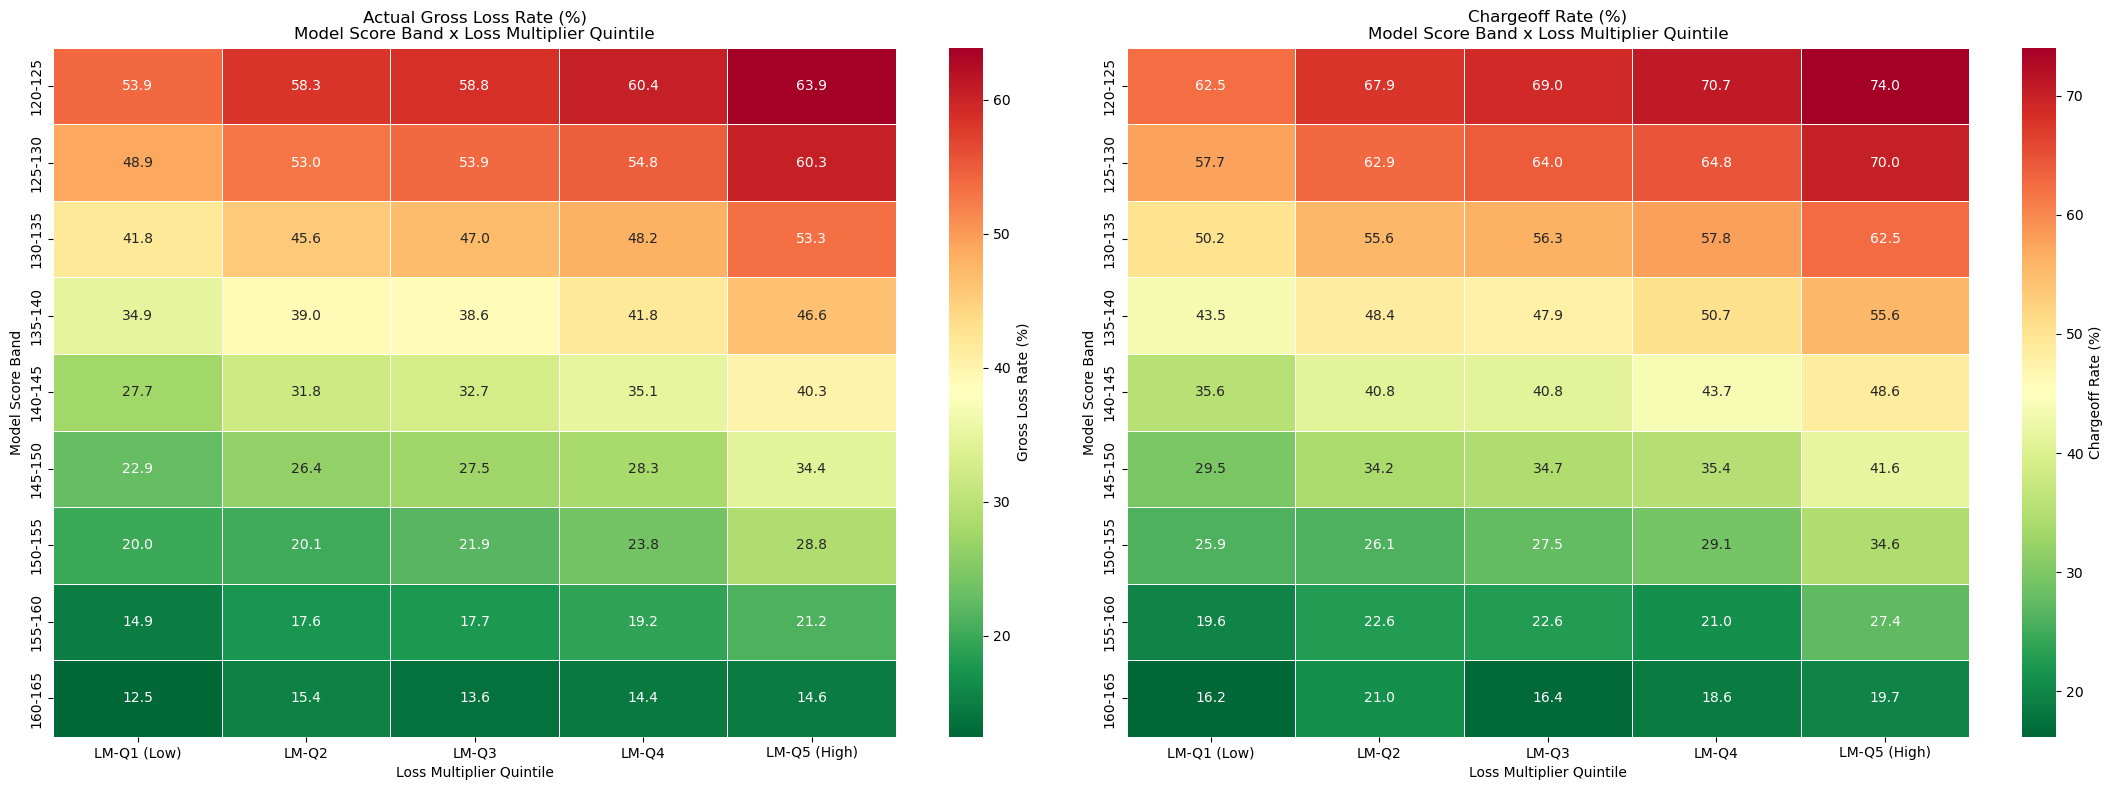

In [12]:
# =============================================================================
# CELL 9: HEATMAP -- ACTUAL GL BY MODEL SCORE BAND x LOSS MULTIPLIER QUINTILE
# =============================================================================

# --- Model score bands (5-point increments) ---
MS_MIN, MS_MAX, MS_STEP = 120, 165, 5
ms_bins = np.arange(MS_MIN, MS_MAX + MS_STEP, MS_STEP)
ms_labels = [f"{b}-{b + MS_STEP}" for b in ms_bins[:-1]]
merged['ms_band_fixed'] = pd.cut(merged['model_score'], bins=ms_bins, labels=ms_labels, right=False)

# --- Loss multiplier quintiles ---
merged['lm_quintile'] = pd.qcut(
    merged['loss_multiplier'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
)

# --- Aggregation ---
analysis_df = merged[merged['ms_band_fixed'].notna()].copy()

grouped = analysis_df.groupby(['ms_band_fixed', 'lm_quintile'], observed=True).agg(
    total_gross_loss=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    loan_count=('account_number', 'count'),
    co_count=('is_chargeoff', 'sum'),
).reset_index()

grouped['gl_rate'] = grouped['total_gross_loss'] / grouped['total_proceeds']
grouped['co_rate'] = grouped['co_count'] / grouped['loan_count']

# --- Pivot tables ---
pivot_gl = grouped.pivot(index='ms_band_fixed', columns='lm_quintile', values='gl_rate')
pivot_count = grouped.pivot(index='ms_band_fixed', columns='lm_quintile', values='loan_count')

print("=" * 90)
print("GROSS LOSS RATE (%) = Gross Loss / Proceeds  --  ALL LOANS")
print("Rows: Model Score bands | Columns: Loss Multiplier quintiles")
print("=" * 90)
display_gl = (pivot_gl * 100).round(2)
display(display_gl)

print(f"\n{'=' * 90}")
print("LOAN COUNT  --  ALL LOANS")
print("Rows: Model Score bands | Columns: Loss Multiplier quintiles")
print("=" * 90)
display_count = pivot_count.fillna(0).astype(int)
display(display_count)

# --- Heatmap: Gross Loss Rate ---
heatmap_data = pivot_gl.copy() * 100
heatmap_data.columns = [f"LM-{c}" for c in heatmap_data.columns]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

ax = axes[0]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Gross Loss Rate (%)'})
ax.set_title('Actual Gross Loss Rate (%)\nModel Score Band x Loss Multiplier Quintile')
ax.set_xlabel('Loss Multiplier Quintile')
ax.set_ylabel('Model Score Band')

# --- Heatmap: Chargeoff Rate ---
pivot_co = grouped.pivot(index='ms_band_fixed', columns='lm_quintile', values='co_rate')
heatmap_co = pivot_co.copy() * 100
heatmap_co.columns = [f"LM-{c}" for c in heatmap_co.columns]

ax = axes[1]
sns.heatmap(heatmap_co, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Chargeoff Rate (%)'})
ax.set_title('Chargeoff Rate (%)\nModel Score Band x Loss Multiplier Quintile')
ax.set_xlabel('Loss Multiplier Quintile')
ax.set_ylabel('Model Score Band')

plt.tight_layout()
plt.savefig('gl_heatmap_ms_x_lm.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# =============================================================================
# CELL 10: ORTHOGONALITY DIAGNOSTICS
# =============================================================================

# --- Loan-level Pearson correlations ---
corr_ms_lm = merged['model_score'].corr(merged['loss_multiplier'])
corr_ms_apr = merged['model_score'].corr(merged['apr'])
corr_lm_apr = merged['loss_multiplier'].corr(merged['apr'])

print("=" * 80)
print("ORTHOGONALITY DIAGNOSTICS")
print("=" * 80)

print(f"\nLoan-level Pearson correlations:")
for label, val in [('model_score vs loss_multiplier', corr_ms_lm),
                   ('model_score vs APR', corr_ms_apr),
                   ('loss_multiplier vs APR', corr_lm_apr)]:
    interp = 'Low' if abs(val) < 0.3 else 'Moderate' if abs(val) < 0.6 else 'High'
    action = 'supports additive' if abs(val) < 0.3 else 'some overlap' if abs(val) < 0.6 else 'redundancy concern'
    print(f"  {label:<40}: {val:>+.4f}  ({interp} -> {action})")

# --- Slope of actual GL vs loss_multiplier within each model_score band ---
print(f"\n{'=' * 80}")
print("REGRESSION: GL Rate vs Loss Multiplier within each Model Score Band")
print("=" * 80)
print(f"\n{'MS Band':<15} {'Slope (GL vs LM)':>18} {'Intercept':>12} {'R²':>8} {'N':>8}")
print("-" * 65)

for ms_label in ms_labels:
    subset = analysis_df[analysis_df['ms_band_fixed'] == ms_label]
    if len(subset) < 50:
        continue
    band_agg = subset.groupby('lm_quintile', observed=True).agg(
        lm_mid=('loss_multiplier', 'mean'),
        gl_rate=('gross_loss_pct', 'mean'),
    ).dropna()
    if len(band_agg) >= 3:
        slope, intercept, r_value, _, _ = linregress(band_agg['lm_mid'], band_agg['gl_rate'])
        print(f"{ms_label:<15} {slope:>+18.6f} {intercept:>+12.6f} {r_value**2:>8.3f} {len(band_agg):>8}")

# --- Slope of actual GL vs model_score within each LM quintile ---
print(f"\n{'=' * 80}")
print("REGRESSION: GL Rate vs Model Score within each Loss Multiplier Quintile")
print("=" * 80)
print(f"\n{'LM Quintile':<15} {'Slope (GL vs MS)':>22} {'R²':>8} {'N bins':>12}")
print("-" * 60)

q_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
for q_label in q_labels:
    subset = analysis_df[analysis_df['lm_quintile'] == q_label]
    if len(subset) < 50:
        continue
    q_agg = subset.groupby('ms_band_fixed', observed=True).agg(
        ms_mid=('model_score', 'mean'),
        gl_rate=('gross_loss_pct', 'mean'),
    ).dropna()
    if len(q_agg) >= 3:
        slope, intercept, r_value, _, _ = linregress(q_agg['ms_mid'], q_agg['gl_rate'])
        print(f"{q_label:<15} {slope:>+22.6f} {r_value**2:>8.3f} {len(q_agg):>12}")

# --- Slope variation diagnostic ---
print(f"\n{'=' * 80}")
print("SLOPE VARIATION: Does the LM slope change across MS bands?")
print("=" * 80)

slopes_by_ms = []
for ms_label in ms_labels:
    subset = analysis_df[analysis_df['ms_band_fixed'] == ms_label]
    if len(subset) < 50:
        continue
    band_agg = subset.groupby('lm_quintile', observed=True).agg(
        lm_mid=('loss_multiplier', 'mean'),
        gl_rate=('gross_loss_pct', 'mean'),
    ).dropna()
    if len(band_agg) >= 3:
        slope, _, _, _, _ = linregress(band_agg['lm_mid'], band_agg['gl_rate'])
        slopes_by_ms.append({'ms_band': ms_label, 'slope': slope})

slopes_df = pd.DataFrame(slopes_by_ms)
if len(slopes_df) >= 3:
    slope_var_cv = slopes_df['slope'].std() / abs(slopes_df['slope'].mean())
    print(f"\n  Slope range: [{slopes_df['slope'].min():.6f}, {slopes_df['slope'].max():.6f}]")
    print(f"  Slope mean:  {slopes_df['slope'].mean():.6f}")
    print(f"  Slope CV:    {slope_var_cv:.2f}")
    print(f"  Interpretation: {'Low variation -> additive OK' if slope_var_cv < 0.5 else 'High variation -> interaction may help'}")

ORTHOGONALITY DIAGNOSTICS

Loan-level Pearson correlations:
  model_score vs loss_multiplier          : -0.1883  (Low -> supports additive)
  model_score vs APR                      : -0.2282  (Low -> supports additive)
  loss_multiplier vs APR                  : +0.1558  (Low -> supports additive)

REGRESSION: GL Rate vs Loss Multiplier within each Model Score Band

MS Band           Slope (GL vs LM)    Intercept       R²        N
-----------------------------------------------------------------
120-125                  +0.167461    +0.429879    0.918        5
125-130                  +0.201133    +0.347222    0.926        5
130-135                  +0.209063    +0.273067    0.954        5
135-140                  +0.211759    +0.202073    0.949        5
140-145                  +0.226717    +0.120682    0.971        5
145-150                  +0.197334    +0.090096    0.947        5
150-155                  +0.155792    +0.075142    0.945        5
155-160                  +0.117563  

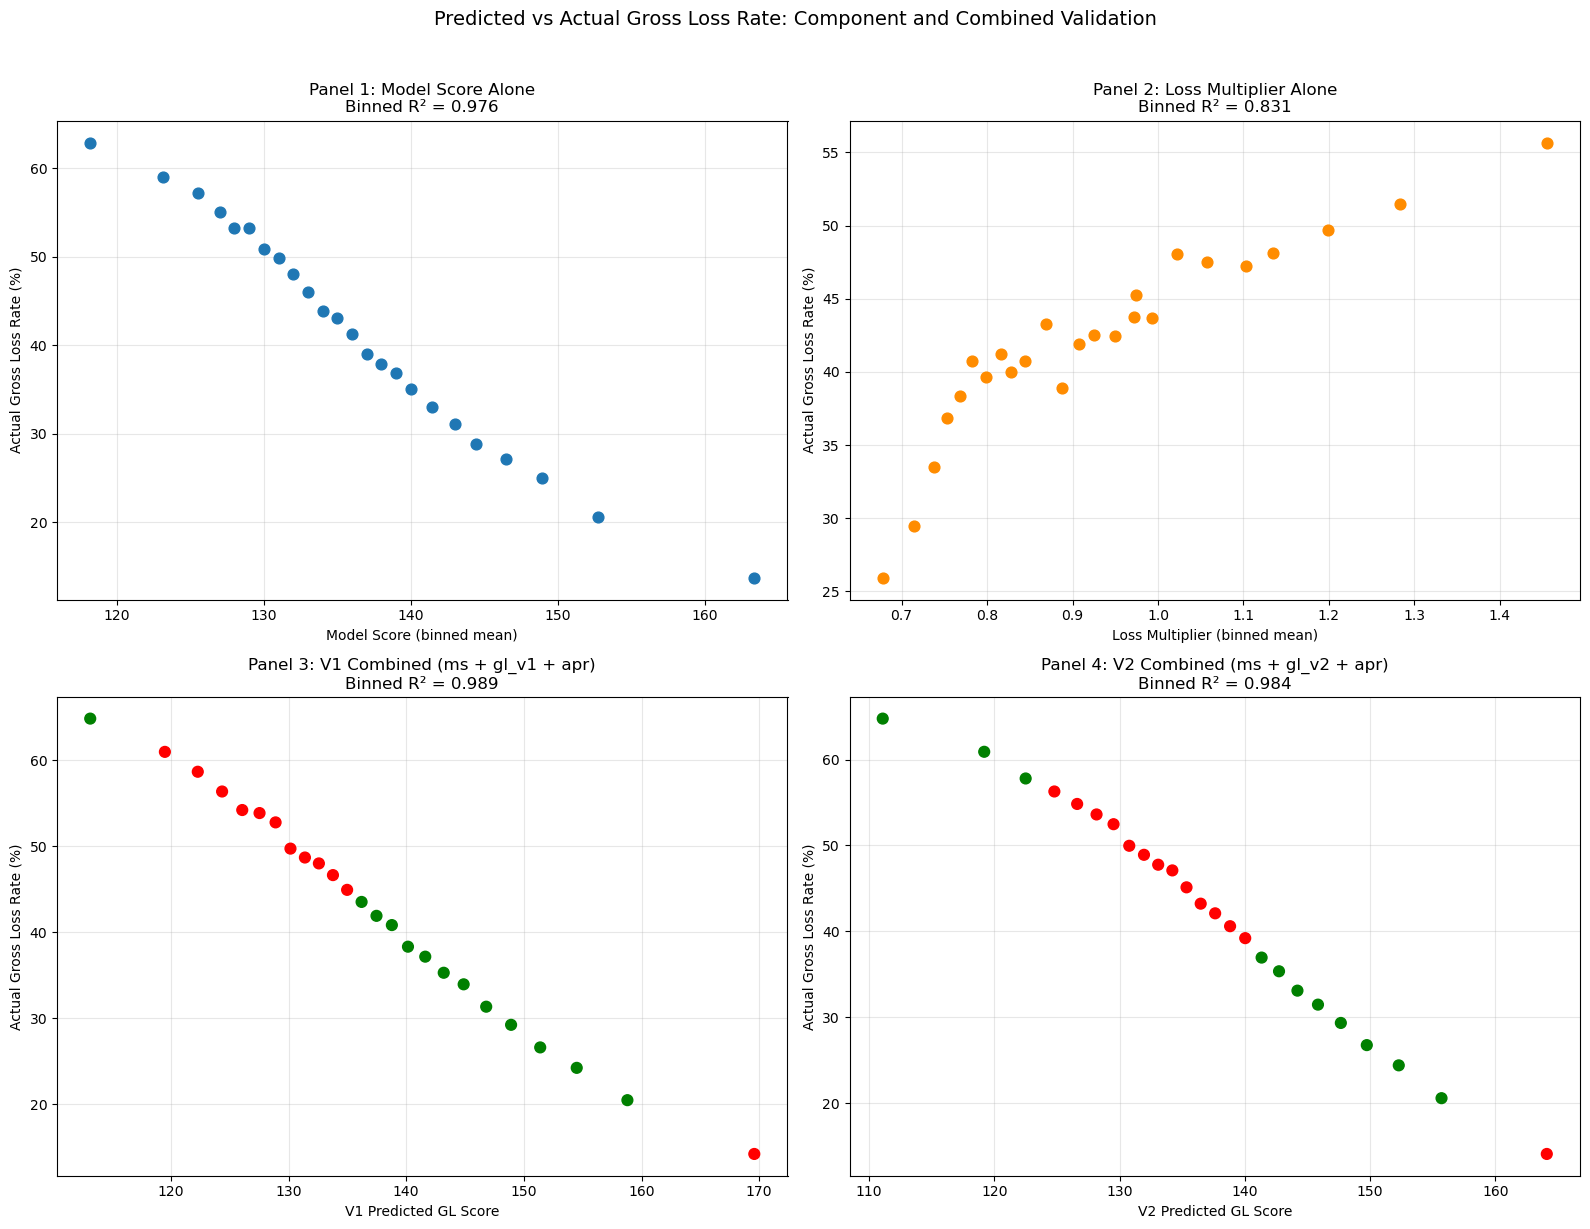

PANEL R² SUMMARY (binned, weighted by proceeds)
  Panel 1: Model Score alone                         0.976
  Panel 2: Loss Multiplier alone                     0.831
  Panel 3: V1 combined (ms + gl_v1 + apr)            0.989
  Panel 4: V2 combined (ms + gl_v2 + apr)            0.984


In [14]:
# =============================================================================
# CELL 11: 4-PANEL PREDICTED VS ACTUAL VALIDATION PLOTS
# =============================================================================

N_PANEL_BINS = 25

# --- Panel data preparation ---
# Panel 1: Model score alone
merged['_bin'] = pd.qcut(merged['model_score'], q=N_PANEL_BINS, duplicates='drop')
by_ms = merged.groupby('_bin', observed=True).agg(
    ms_mid=('model_score', 'mean'),
    actual=('gross_loss_pct', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
by_ms['weighted_actual'] = by_ms['total_gl'] / by_ms['total_proceeds']
merged.drop(columns='_bin', inplace=True)

# Panel 2: Loss multiplier alone
merged['_bin'] = pd.qcut(merged['loss_multiplier'], q=N_PANEL_BINS, duplicates='drop')
by_lm = merged.groupby('_bin', observed=True).agg(
    lm_mid=('loss_multiplier', 'mean'),
    actual=('gross_loss_pct', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
by_lm['weighted_actual'] = by_lm['total_gl'] / by_lm['total_proceeds']
merged.drop(columns='_bin', inplace=True)

# Panel 3: V1 combined predicted vs actual
merged['_bin'] = pd.qcut(merged['gl_predicted_v1'], q=N_PANEL_BINS, duplicates='drop')
by_v1 = merged.groupby('_bin', observed=True).agg(
    pred_mid=('gl_predicted_v1', 'mean'),
    actual=('gross_loss_pct', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    median_book=('book_date', 'median'),
).reset_index()
by_v1['weighted_actual'] = by_v1['total_gl'] / by_v1['total_proceeds']
merged.drop(columns='_bin', inplace=True)

# Panel 4: V2 combined predicted vs actual
merged['_bin'] = pd.qcut(merged['gl_predicted_v2'], q=N_PANEL_BINS, duplicates='drop')
by_v2 = merged.groupby('_bin', observed=True).agg(
    pred_mid=('gl_predicted_v2', 'mean'),
    actual=('gross_loss_pct', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    median_book=('book_date', 'median'),
).reset_index()
by_v2['weighted_actual'] = by_v2['total_gl'] / by_v2['total_proceeds']
merged.drop(columns='_bin', inplace=True)

# --- R-squared for each ---
_, _, r_panel1, _, _ = linregress(by_ms['ms_mid'], by_ms['weighted_actual'])
_, _, r_panel2, _, _ = linregress(by_lm['lm_mid'], by_lm['weighted_actual'])
_, _, r_panel3, _, _ = linregress(by_v1['pred_mid'], by_v1['weighted_actual'])
_, _, r_panel4, _, _ = linregress(by_v2['pred_mid'], by_v2['weighted_actual'])

# --- 4-panel figure ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Model score
ax = axes[0, 0]
ax.scatter(by_ms['ms_mid'], by_ms['weighted_actual'] * 100, s=60, zorder=3)
ax.set_xlabel('Model Score (binned mean)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'Panel 1: Model Score Alone\nBinned R² = {r_panel1**2:.3f}')
ax.grid(True, alpha=0.3)

# Panel 2: Loss multiplier
ax = axes[0, 1]
ax.scatter(by_lm['lm_mid'], by_lm['weighted_actual'] * 100, s=60, color='darkorange', zorder=3)
ax.set_xlabel('Loss Multiplier (binned mean)')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'Panel 2: Loss Multiplier Alone\nBinned R² = {r_panel2**2:.3f}')
ax.grid(True, alpha=0.3)

# Panel 3: V1 combined
ax = axes[1, 0]
residuals_v1 = by_v1['weighted_actual'] - (by_v1['pred_mid'] * linregress(by_v1['pred_mid'], by_v1['weighted_actual']).slope
                                             + linregress(by_v1['pred_mid'], by_v1['weighted_actual']).intercept)
colors_v1 = ['green' if r < 0 else 'red' for r in residuals_v1]
ax.scatter(by_v1['pred_mid'], by_v1['weighted_actual'] * 100, s=60, c=colors_v1, zorder=3)
min_v = min(by_v1['pred_mid'].min(), by_v1['weighted_actual'].min() * 100 / 100)
max_v = max(by_v1['pred_mid'].max(), by_v1['weighted_actual'].max())
ax.set_xlabel('V1 Predicted GL Score')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'Panel 3: V1 Combined (ms + gl_v1 + apr)\nBinned R² = {r_panel3**2:.3f}')
ax.grid(True, alpha=0.3)

# Panel 4: V2 combined
ax = axes[1, 1]
residuals_v2 = by_v2['weighted_actual'] - (by_v2['pred_mid'] * linregress(by_v2['pred_mid'], by_v2['weighted_actual']).slope
                                             + linregress(by_v2['pred_mid'], by_v2['weighted_actual']).intercept)
colors_v2 = ['green' if r < 0 else 'red' for r in residuals_v2]
ax.scatter(by_v2['pred_mid'], by_v2['weighted_actual'] * 100, s=60, c=colors_v2, zorder=3)
ax.set_xlabel('V2 Predicted GL Score')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'Panel 4: V2 Combined (ms + gl_v2 + apr)\nBinned R² = {r_panel4**2:.3f}')
ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual Gross Loss Rate: Component and Combined Validation',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('gl_validation_panels.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("PANEL R² SUMMARY (binned, weighted by proceeds)")
print("=" * 80)
print(f"  {'Panel 1: Model Score alone':<45} {r_panel1**2:>10.3f}")
print(f"  {'Panel 2: Loss Multiplier alone':<45} {r_panel2**2:>10.3f}")
print(f"  {'Panel 3: V1 combined (ms + gl_v1 + apr)':<45} {r_panel3**2:>10.3f}")
print(f"  {'Panel 4: V2 combined (ms + gl_v2 + apr)':<45} {r_panel4**2:>10.3f}")

ALTERNATIVE FORMULA EXPLORATION

--- 12A: Grid Search (constant UL x conversion factor) ---
      UL   Factor    R² (loan-level)    Binned R²
--------------------------------------------------
    0.50    0.020        0.08457       (V1 default)
      V2    0.027        0.08431       (V2 default)
    0.50    0.018        0.08457       (BEST constant UL)

--- 12B: Score-Dependent UL (V2-style) with different slopes ---
  V2 formula: UL = 0.9 - (ms - 125) * slope - (72 - term) / 240

   Slope    R² (loan-level)                Notes
--------------------------------------------------
   0.002        0.08455       
   0.004        0.08458       
   0.006        0.08461       
   0.008        0.08463       
   0.010        0.08464       
   0.012        0.08465       
   0.015        0.08464       
   0.018        0.08461       
   0.020        0.08457       <-- V1 default
   0.022        0.08452       
   0.025        0.08440       
   0.027        0.08431       <-- V2 default
   0.030      

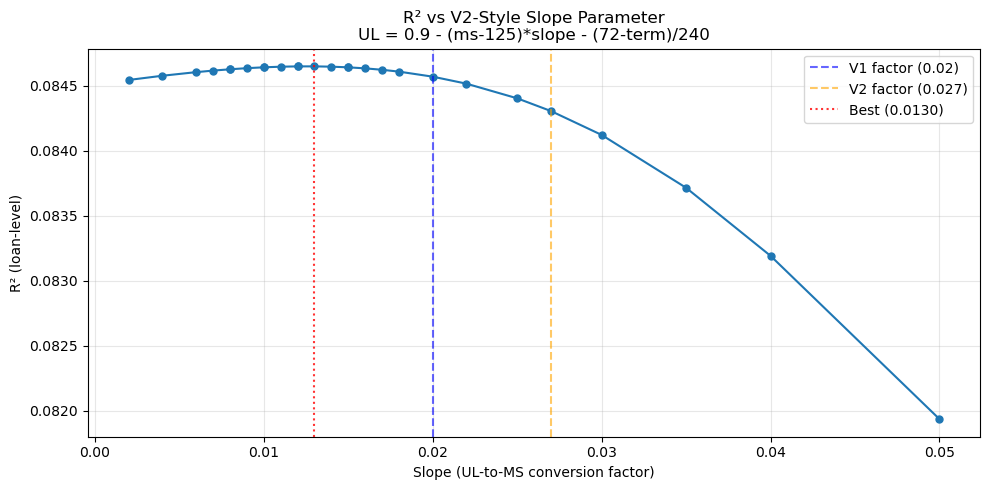


--- 12C: Nonlinear Loss Multiplier Transforms ---
                     Transform         R²
---------------------------------------------
               Linear (1 - LM)    0.08457
            Squared (1 - LM)^2    0.07998
                       Log(LM)    0.08438
                  Sqrt(1 - LM)    0.08436
                          1/LM    0.08405
             (1-LM) + (1-LM)^2    0.08460

--- 12D: OLS-Optimal Formula (fully data-driven) ---
  Intercept:       +1.528193
  model_score:     -0.011102
  loss_multiplier: +0.183337
  APR:             +0.912981
  R²:              0.08550

  Implied UL/factor ratio: 0.1833
    V1 uses: 25.0 (0.5/0.02)
    V2 uses: ~18.5 (UL~0.5 / 0.027) at mean score
    OLS implied: 0.1833 (data-driven)


In [15]:
# =============================================================================
# CELL 12: ALTERNATIVE FORMULA EXPLORATION
# =============================================================================

print("=" * 100)
print("ALTERNATIVE FORMULA EXPLORATION")
print("=" * 100)

# --- 12A: Grid search over constant UL and conversion factor ---
print("\n--- 12A: Grid Search (constant UL x conversion factor) ---")
print(f"{'UL':>8} {'Factor':>8} {'R² (loan-level)':>18} {'Binned R²':>12}")
print("-" * 50)

ul_values = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
factor_values = [0.015, 0.018, 0.020, 0.022, 0.025, 0.027, 0.030, 0.035]

best_r2_const = -1
best_params_const = {}

for ul in ul_values:
    for factor in factor_values:
        gl_impact = (1 - valid['loss_multiplier']) * ul / factor
        X = np.column_stack([valid['model_score'].values, gl_impact.values, valid['apr_impact'].values])
        lr = LinearRegression().fit(X, y)
        r2 = r2_score(y, lr.predict(X))

        if r2 > best_r2_const:
            best_r2_const = r2
            best_params_const = {'ul': ul, 'factor': factor, 'r2': r2}

# Print only the V1/V2 defaults and the best
print(f"  {V1_UL:>6.2f}   {V1_UL_TO_MS:>6.3f}   {models['M6: V1 full (ms + gl_v1 + apr)']['r2']:>12.5f}       (V1 default)")
print(f"  {'V2':>6s}   {V2_UL_TO_MS:>6.3f}   {models['M7: V2 full (ms + gl_v2 + apr)']['r2']:>12.5f}       (V2 default)")
print(f"  {best_params_const['ul']:>6.2f}   {best_params_const['factor']:>6.3f}   {best_params_const['r2']:>12.5f}       (BEST constant UL)")

# --- 12B: Score-dependent UL with different slopes ---
print(f"\n--- 12B: Score-Dependent UL (V2-style) with different slopes ---")
print(f"  V2 formula: UL = 0.9 - (ms - 125) * slope - (72 - term) / 240")
print(f"\n{'Slope':>8} {'R² (loan-level)':>18} {'Notes':>20}")
print("-" * 50)

slopes_coarse = [0.002, 0.004, 0.006, 0.008, 0.010, 0.012, 0.015,
                 0.018, 0.020, 0.022, 0.025, 0.027, 0.030, 0.035, 0.040, 0.050]
best_r2_slope = -1
best_slope = None
slope_results = []

for slope_val in slopes_coarse:
    ul_dynamic = 0.9 - (valid['model_score'] - 125) * slope_val - (72 - valid['con_term_filled']) / 240
    gl_impact = (1 - valid['loss_multiplier']) * ul_dynamic / slope_val
    X = np.column_stack([valid['model_score'].values, gl_impact.values, valid['apr_impact'].values])
    lr = LinearRegression().fit(X, y)
    r2 = r2_score(y, lr.predict(X))
    slope_results.append({'slope': slope_val, 'r2': r2})

    note = ""
    if slope_val == V1_UL_TO_MS:
        note = "<-- V1 default"
    elif slope_val == V2_UL_TO_MS:
        note = "<-- V2 default"
    if r2 > best_r2_slope:
        best_r2_slope = r2
        best_slope = slope_val

    print(f"  {slope_val:>6.3f}   {r2:>12.5f}       {note}")

print(f"\n  Coarse best: slope={best_slope:.3f} (R² = {best_r2_slope:.5f})")

# Fine-grained search around the coarse best
fine_lo = max(best_slope - 0.005, 0.001)
fine_hi = best_slope + 0.005
slopes_fine = np.arange(fine_lo, fine_hi + 0.0005, 0.001)
print(f"\n  Fine-grained search [{fine_lo:.3f}, {fine_hi:.3f}]:")
print(f"  {'Slope':>8} {'R²':>12}")
print("  " + "-" * 24)

for slope_val in slopes_fine:
    ul_dynamic = 0.9 - (valid['model_score'] - 125) * slope_val - (72 - valid['con_term_filled']) / 240
    gl_impact = (1 - valid['loss_multiplier']) * ul_dynamic / slope_val
    X = np.column_stack([valid['model_score'].values, gl_impact.values, valid['apr_impact'].values])
    lr = LinearRegression().fit(X, y)
    r2 = r2_score(y, lr.predict(X))
    slope_results.append({'slope': slope_val, 'r2': r2})

    marker = " <-- BEST" if r2 > best_r2_slope else ""
    if r2 > best_r2_slope:
        best_r2_slope = r2
        best_slope = slope_val
    print(f"  {slope_val:>8.4f}   {r2:>10.5f}{marker}")

slopes_to_test = slopes_coarse
print(f"\n  Final best slope: {best_slope:.4f} (R² = {best_r2_slope:.5f})")

# Plot R² vs slope
slope_res_df = pd.DataFrame(slope_results).sort_values('slope')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slope_res_df['slope'], slope_res_df['r2'], 'o-', markersize=5)
ax.axvline(V1_UL_TO_MS, color='blue', linestyle='--', alpha=0.6, label=f'V1 factor ({V1_UL_TO_MS})')
ax.axvline(V2_UL_TO_MS, color='orange', linestyle='--', alpha=0.6, label=f'V2 factor ({V2_UL_TO_MS})')
ax.axvline(best_slope, color='red', linestyle=':', alpha=0.8, label=f'Best ({best_slope:.4f})')
ax.set_xlabel('Slope (UL-to-MS conversion factor)')
ax.set_ylabel('R² (loan-level)')
ax.set_title('R² vs V2-Style Slope Parameter\nUL = 0.9 - (ms-125)*slope - (72-term)/240')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gl_slope_search.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 12C: Nonlinear loss_multiplier transforms ---
print(f"\n--- 12C: Nonlinear Loss Multiplier Transforms ---")
print(f"{'Transform':>30} {'R²':>10}")
print("-" * 45)

transforms = {
    'Linear (1 - LM)':            (1 - valid['loss_multiplier']),
    'Squared (1 - LM)^2':         (1 - valid['loss_multiplier']) ** 2,
    'Log(LM)':                     np.log(valid['loss_multiplier'].clip(lower=0.01)),
    'Sqrt(1 - LM)':               np.sqrt(np.abs(1 - valid['loss_multiplier'])) * np.sign(1 - valid['loss_multiplier']),
    '1/LM':                        1 / valid['loss_multiplier'].clip(lower=0.01),
    '(1-LM) + (1-LM)^2':          None,
}

for name, transform in transforms.items():
    if name == '(1-LM) + (1-LM)^2':
        lm_dev = 1 - valid['loss_multiplier']
        X = np.column_stack([valid['model_score'].values, lm_dev.values, (lm_dev ** 2).values, valid['apr_impact'].values])
    else:
        X = np.column_stack([valid['model_score'].values, transform.values, valid['apr_impact'].values])
    lr = LinearRegression().fit(X, y)
    r2 = r2_score(y, lr.predict(X))
    print(f"  {name:>28s}   {r2:>8.5f}")

# --- 12D: OLS-optimal formula (data-driven) ---
print(f"\n--- 12D: OLS-Optimal Formula (fully data-driven) ---")
X_opt = valid[['model_score', 'loss_multiplier', 'apr']].values
lr_opt = LinearRegression().fit(X_opt, y)
r2_opt = r2_score(y, lr_opt.predict(X_opt))

print(f"  Intercept:       {lr_opt.intercept_:>+.6f}")
print(f"  model_score:     {lr_opt.coef_[0]:>+.6f}")
print(f"  loss_multiplier: {lr_opt.coef_[1]:>+.6f}")
print(f"  APR:             {lr_opt.coef_[2]:>+.6f}")
print(f"  R²:              {r2_opt:.5f}")

# Implied conversion: if gl_impact = (1-LM) * UL / factor maps to the same coefficient
# OLS gives: coef_LM = -UL/factor (negative because higher LM = lower loss)
implied_ratio = abs(lr_opt.coef_[1])
print(f"\n  Implied UL/factor ratio: {implied_ratio:.4f}")
print(f"    V1 uses: {V1_UL / V1_UL_TO_MS:.1f} (0.5/0.02)")
print(f"    V2 uses: ~{0.5 / V2_UL_TO_MS:.1f} (UL~0.5 / 0.027) at mean score")
print(f"    OLS implied: {implied_ratio:.4f} (data-driven)")

In [16]:
# =============================================================================
# CELL 13: SUMMARY TABLE AND RECOMMENDATIONS
# =============================================================================

print("=" * 110)
print("GROSS LOSS VALIDATION STUDY: SUMMARY OF ALL MODEL SPECIFICATIONS")
print("=" * 110)

summary_rows = []

# Loan-level models from Cell 7
for name, info in models.items():
    summary_rows.append({
        'Specification': name,
        'R² (loan-level)': info['r2'],
        'Adj R²': info['adj_r2'],
        'Type': 'Loan-level OLS',
    })

# Best constant UL from grid search
summary_rows.append({
    'Specification': f"Best Constant UL (UL={best_params_const['ul']}, factor={best_params_const['factor']})",
    'R² (loan-level)': best_params_const['r2'],
    'Adj R²': np.nan,
    'Type': 'Grid Search',
})

# Best V2-style slope (already computed in Cell 12)
summary_rows.append({
    'Specification': f"Best V2-style slope={best_slope:.4f}",
    'R² (loan-level)': best_r2_slope,
    'Adj R²': np.nan,
    'Type': 'V2 Slope Search',
})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('R² (loan-level)', ascending=False).reset_index(drop=True)

print(f"\n{'Rank':>4} {'Specification':<55} {'R²':>10} {'Adj R²':>10} {'Type':>20}")
print("-" * 105)
for i, row in summary_df.iterrows():
    adj_str = f"{row['Adj R²']:.5f}" if pd.notna(row['Adj R²']) else "    --"
    print(f"{i+1:>4} {row['Specification']:<55} {row['R² (loan-level)']:>10.5f} {adj_str:>10} {row['Type']:>20}")

# --- Key findings ---
best_model = summary_df.iloc[0]
v1_r2 = models['M6: V1 full (ms + gl_v1 + apr)']['r2']
v2_r2 = models['M7: V2 full (ms + gl_v2 + apr)']['r2']
ols_r2 = models['M9: OLS-optimal (ms, LM, APR)']['r2']

print(f"\n{'=' * 110}")
print("KEY FINDINGS")
print("=" * 110)
print(f"\n  1. V1 gross-loss R²: {v1_r2:.5f}")
print(f"     V2 gross-loss R²: {v2_r2:.5f}")
print(f"     Difference:       {v2_r2 - v1_r2:+.5f} ({'V2 better' if v2_r2 > v1_r2 else 'V1 better'})")

print(f"\n  2. OLS-optimal R²:  {ols_r2:.5f}")
print(f"     Improvement over V1: {ols_r2 - v1_r2:+.5f}")
print(f"     Improvement over V2: {ols_r2 - v2_r2:+.5f}")

print(f"\n  3. Best specification: {best_model['Specification']}")
print(f"     R²: {best_model['R² (loan-level)']:.5f}")

# Univariate contributions recap
print(f"\n  4. Univariate R² contributions (binned):")
print(f"     Model Score alone:      {r_panel1**2:.3f}")
print(f"     Loss Multiplier alone:  {r_panel2**2:.3f}")

print(f"\n  5. Orthogonality:")
print(f"     Corr(model_score, loss_multiplier): {corr_ms_lm:+.4f}")
print(f"     Corr(model_score, APR):             {corr_ms_apr:+.4f}")
print(f"     Corr(loss_multiplier, APR):         {corr_lm_apr:+.4f}")

print(f"\n{'=' * 110}")
print("RECOMMENDATIONS")
print("=" * 110)
print("""
  These results should be interpreted with the following caveats:

  a) loss_multiplier was back-derived from V1 gross_loss_impact, which
     introduces a mechanical dependency between V1 predictions and the
     loss_multiplier variable. V2 predictions using this same loss_multiplier
     are a fair comparison, but absolute R-squared values should be
     interpreted directionally.

  b) The maturity cutoff (book_date <= 2023-12-31) means only vintages with
     sufficient seasoning contribute to the analysis. Newer vintages with
     different risk profiles are excluded.

  c) con_term was filled with 72 months where missing. This approximation
     affects V2 unit_loss computation for loans without term data.

  Run this notebook to compare V1 vs V2 and evaluate whether alternative
  specifications (OLS-optimal coefficients, different conversion factors,
  nonlinear transforms) materially outperform the existing formulas.
""")

GROSS LOSS VALIDATION STUDY: SUMMARY OF ALL MODEL SPECIFICATIONS

Rank Specification                                                   R²     Adj R²                 Type
---------------------------------------------------------------------------------------------------------
   1 M8: ms + LM + APR + ms*LM                                  0.08564    0.08563       Loan-level OLS
   2 M5: ms + LM + APR (raw inputs)                             0.08550    0.08549       Loan-level OLS
   3 M9: OLS-optimal (ms, LM, APR)                              0.08550    0.08549       Loan-level OLS
   4 Best V2-style slope=0.0130                                 0.08465         --      V2 Slope Search
   5 Best Constant UL (UL=0.5, factor=0.018)                    0.08457         --          Grid Search
   6 M6: V1 full (ms + gl_v1 + apr)                             0.08457    0.08457       Loan-level OLS
   7 M7: V2 full (ms + gl_v2 + apr)                             0.08431    0.08430       Loan-level 

RECOMMENDED GROSS-LOSS FORMULA (derived from OLS-optimal coefficients)

  OLS regression on raw inputs (R² = 0.08550):

    gross_loss_pct = +1.5282  -0.011102 * model_score
                                    +0.183337 * loss_multiplier
                                    +0.912981 * APR

  Anchor: |coef_ms| = 0.011102  (gross loss rate change per 1 model-score point)

  RAGU Score-Point Equivalent Formula:
  ----------------------------------------------------------------------

    gl_ragu = model_score
            + (1 - loss_multiplier) * 16.51
            + (baseline_apr - apr) / 0.01 * 0.8223

PARAMETER COMPARISON: V1 vs V2 vs OLS-Recommended

Parameter                                          V1           V2      OLS-Rec
--------------------------------------------------------------------------------
Unit loss (UL)..........................         0.50 0.596 (varies)          N/A
UL-to-MS factor.........................        0.020        0.027          N/A
GL multiplier = UL

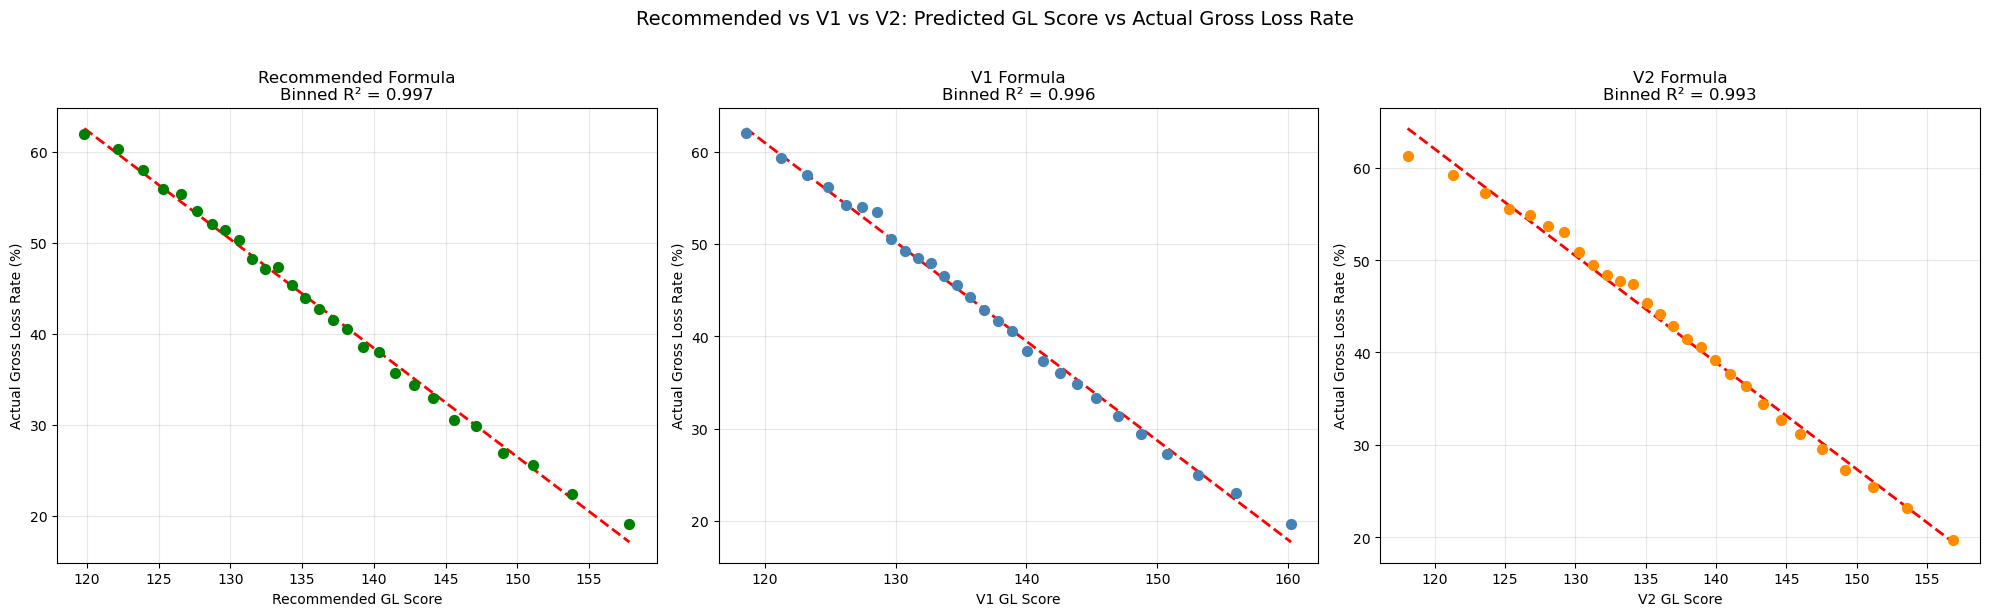

LOB-STRATIFIED REGRESSIONS: Do coefficients vary materially by LOB?

LOB             N      coef_ms      coef_LM     coef_APR       R²    GL mult   APR mult
-------------------------------------------------------------------------------------
AN          25624    -0.013385    +0.181299    +0.635879  0.09793      13.55     0.4751
ENT         55226    -0.016588    +0.211588    +0.728966  0.07090      12.76     0.4394
FLD         14348    -0.011971    +0.019167    +1.135490  0.07963       1.60     0.9485
FRN         46083    -0.014523    +0.298208    +0.842994  0.12152      20.53     0.5805
KMX        261592    -0.009770    +0.167308    +0.883345  0.07746      17.13     0.9042
STG         46953    -0.013479    +0.215315    +1.104279  0.12533      15.97     0.8193

  Pooled (all LOBs): GL mult = 16.51, APR mult = 0.8223
  GL multiplier CV across LOBs:  0.48  (Material variation -- consider LOB-specific)
  APR multiplier CV across LOBs: 0.32  (Material variation -- consider LOB-specific)

F

In [19]:
# =============================================================================
# CELL 14: RECOMMENDED GROSS-LOSS FORMULA
# =============================================================================

# --- Extract OLS-optimal coefficients (M5/M9: ms, LM, APR raw inputs) ---
lr_opt = models['M9: OLS-optimal (ms, LM, APR)']['model']
coef_ms = lr_opt.coef_[0]
coef_lm = lr_opt.coef_[1]
coef_apr = lr_opt.coef_[2]
intercept = lr_opt.intercept_

# --- Derive RAGU-equivalent parameters ---
# Each model-score point changes gross_loss_pct by |coef_ms|
# Normalize other coefficients relative to this anchor
implied_gl_factor = abs(coef_lm / coef_ms)
implied_apr_per_pct = abs(coef_apr / coef_ms) / 100

print("=" * 100)
print("RECOMMENDED GROSS-LOSS FORMULA (derived from OLS-optimal coefficients)")
print("=" * 100)

print(f"""
  OLS regression on raw inputs (R² = {models['M9: OLS-optimal (ms, LM, APR)']['r2']:.5f}):

    gross_loss_pct = {intercept:+.4f}  {coef_ms:+.6f} * model_score
                                    {coef_lm:+.6f} * loss_multiplier
                                    {coef_apr:+.6f} * APR

  Anchor: |coef_ms| = {abs(coef_ms):.6f}  (gross loss rate change per 1 model-score point)
""")

print("  RAGU Score-Point Equivalent Formula:")
print("  " + "-" * 70)
print(f"""
    gl_ragu = model_score
            + (1 - loss_multiplier) * {implied_gl_factor:.2f}
            + (baseline_apr - apr) / 0.01 * {implied_apr_per_pct:.4f}
""")

# --- Side-by-side parameter comparison ---
print("=" * 100)
print("PARAMETER COMPARISON: V1 vs V2 vs OLS-Recommended")
print("=" * 100)

v2_mean_ul = 0.9 - (valid['model_score'].mean() - 125) * 0.027 - (72 - valid['con_term_filled'].mean()) / 240
v2_implied_factor = v2_mean_ul / 0.027

header = f"{'Parameter':<40} {'V1':>12} {'V2':>12} {'OLS-Rec':>12}"
print(f"\n{header}")
print("-" * 80)
print(f"{'Unit loss (UL)':.<40} {'0.50':>12} {f'{v2_mean_ul:.3f} (varies)':>12} {'   N/A':>12}")
print(f"{'UL-to-MS factor':.<40} {'0.020':>12} {'0.027':>12} {'   N/A':>12}")
print(f"{'GL multiplier = UL / factor':.<40} {'25.00':>12} {f'{v2_implied_factor:.2f} (varies)':>12} {f'{implied_gl_factor:.2f}':>12}")
print(f"{'APR multiplier (per 1% APR)':.<40} {'0.700':>12} {'0.700':>12} {f'{implied_apr_per_pct:.4f}':>12}")
ols_r2_str = f"{models['M9: OLS-optimal (ms, LM, APR)']['r2']:.5f}"
print(f"{'R² (loan-level, full model)':.<40} {'0.08457':>12} {'0.08431':>12} {ols_r2_str:>12}")

pct_overweight_v1 = (25.0 / implied_gl_factor - 1) * 100
pct_overweight_v2 = (v2_implied_factor / implied_gl_factor - 1) * 100
print(f"""
  Interpretation:
    - V1 overweights loss_multiplier by {pct_overweight_v1:.0f}% (25.0 vs {implied_gl_factor:.2f})
    - V2 overweights loss_multiplier by {pct_overweight_v2:.0f}% ({v2_implied_factor:.2f} vs {implied_gl_factor:.2f}) at mean score
    - V1/V2 underweight APR by {(1 - 0.7 / implied_apr_per_pct) * 100:.0f}% (0.70 vs {implied_apr_per_pct:.4f})
""")

# --- Theoretical Reconciliation ---
print("=" * 100)
print("THEORETICAL RECONCILIATION: Expressing 16.51 in V2 Terms")
print("=" * 100)

mean_ms = valid['model_score'].mean()
mean_term = valid['con_term_filled'].mean()
ul_at_mean = 0.9 - (mean_ms - 125) * 0.027 - (72 - mean_term) / 240
v2_factor = 0.027

# Implied UL if we keep V2's factor
implied_ul = implied_gl_factor * v2_factor

# Implied factor if we keep V2's UL at population mean
implied_factor = ul_at_mean / implied_gl_factor

print(f"""
  V2 theoretical gross-loss impact (Ragu_v_two.ipynb):

    gross_loss_impact = (1 - loss_multiplier) * UL / factor

    where:
      UL    = 0.9 - (model_score - 125) * 0.027 - (72 - term) / 240
      factor = 0.027  (unit-loss-to-model-score conversion)

  At population mean (ms={mean_ms:.1f}, term={mean_term:.1f}):
      UL    = 0.9 - ({mean_ms:.1f} - 125) * 0.027 - (72 - {mean_term:.1f}) / 240 = {ul_at_mean:.4f}
      V2 GL multiplier = UL / factor = {ul_at_mean:.4f} / 0.027 = {ul_at_mean/0.027:.2f}

  OLS-empirical GL multiplier = {implied_gl_factor:.2f}

  Two equivalent ways to express 16.51 in V2 terms:
  -----------------------------------------------------------------------
  Option A: Keep factor = 0.027, solve for UL
      UL_implied = {implied_gl_factor:.2f} * 0.027 = {implied_ul:.4f}
      Interpretation: the effective unit loss is {implied_ul:.2%} of proceeds,
      {((implied_ul / ul_at_mean) - 1)*100:+.1f}% vs V2's UL at mean ({ul_at_mean:.4f})

  Option B: Keep UL = {ul_at_mean:.4f} (V2 at mean), solve for factor
      factor_implied = {ul_at_mean:.4f} / {implied_gl_factor:.2f} = {implied_factor:.6f}
      Interpretation: each model-score point corresponds to {implied_factor:.4f} of
      unit loss, vs V2's 0.027 and V1's 0.020
  -----------------------------------------------------------------------

  Key insight: V2's UL/factor RATIO is already close to the empirical optimum
  ({ul_at_mean/0.027:.2f} vs {implied_gl_factor:.2f}), but making UL score-dependent
  does not improve fit. A constant multiplier of {implied_gl_factor:.2f} is sufficient.

  Recommended V2-compatible expression:

    gross_loss_impact = (1 - loss_multiplier) * {implied_ul:.4f} / 0.027

  Or equivalently (collapsing UL and factor into a single constant):

    gross_loss_impact = (1 - loss_multiplier) * {implied_gl_factor:.2f}
""")

# --- Empirical Validation of ul_to_ms = 0.027 ---
print("=" * 100)
print("EMPIRICAL VALIDATION: Is the PD-to-Model-Score slope actually 0.027?")
print("=" * 100)

# Unit loss = probability of default (binary: did the loan charge off?)
valid['defaulted'] = (valid['gross_loss_amt'] > 0).astype(int)

# Loan-level regression: PD = f(model_score)
from scipy.stats import linregress as lr
slope_pd_ms, intercept_pd_ms, r_pd_ms, _, _ = lr(valid['model_score'], valid['defaulted'])

# Binned validation for cleaner slope
ms_bins_pd = pd.cut(valid['model_score'], bins=range(120, 170, 5))
pd_by_ms = valid.groupby(ms_bins_pd, observed=True).agg(
    mean_ms=('model_score', 'mean'),
    default_rate=('defaulted', 'mean'),
    count=('account_number', 'count'),
).reset_index()

slope_pd_binned, int_pd_binned, r_pd_binned, _, _ = lr(pd_by_ms['mean_ms'], pd_by_ms['default_rate'])

print(f"""
  Theory (V2): ul_to_ms = 0.027
    Meaning: each +1 model-score point reduces PD by 0.027

  Empirical (loan-level linear regression: defaulted ~ model_score):
    Slope:       {slope_pd_ms:.6f}  (PD change per 1 model-score point)
    Intercept:   {intercept_pd_ms:.4f}
    R²:          {r_pd_ms**2:.5f}
    N:           {len(valid):,}

  Empirical (binned, 5-pt MS bands):
    Slope:       {slope_pd_binned:.6f}
    R²:          {r_pd_binned**2:.4f}

  Comparison:
    V2 assumed:     0.027000
    Empirical:      {abs(slope_pd_ms):.6f}
    Ratio:          {0.027 / abs(slope_pd_ms):.2f}x  (V2 {'over' if 0.027 > abs(slope_pd_ms) else 'under'}estimates by {abs(0.027 / abs(slope_pd_ms) - 1)*100:.0f}%)
""")

# Show PD by model score band
print(f"  {'MS Band':<12} {'Default Rate':>14} {'N':>10}")
print(f"  {'-'*40}")
for _, row in pd_by_ms.iterrows():
    print(f"  {row.name:<12} {row['default_rate']:>14.4f} {row['count']:>10,.0f}")

# Also check: does loss_multiplier relate to PD differently than to GL rate?
slope_pd_lm, int_pd_lm, r_pd_lm, _, _ = lr(valid['loss_multiplier'], valid['defaulted'])

empirical_ul_to_ms = abs(slope_pd_ms)

# Overall population-level severity: GL% / PD%
overall_gl_rate = valid['gross_loss_pct'].mean()
overall_pd_rate = valid['defaulted'].mean()
severity_ratio = overall_gl_rate / overall_pd_rate

print(f"""
  Overall Gross Loss % / Overall Unit Loss (PD) %:
    Mean gross loss rate (all loans):   {overall_gl_rate:.4f}  ({overall_gl_rate*100:.2f}%)
    Mean default rate (all loans):      {overall_pd_rate:.4f}  ({overall_pd_rate*100:.2f}%)
    Ratio (GL% / PD%):                  {severity_ratio:.4f}  ({severity_ratio*100:.1f}%)

    Interpretation: {severity_ratio*100:.1f}% of unit loss converts to gross loss.
    The remaining {(1-severity_ratio)*100:.1f}% is recovered (collateral, repo, etc.)
""")

# --- Combined factor decomposition ---
print("=" * 100)
print("FACTOR DECOMPOSITION: PD slope x Severity = Combined GL-per-score-point factor")
print("=" * 100)

combined_factor = abs(coef_ms)
empirical_severity = combined_factor / empirical_ul_to_ms
effective_ul = abs(coef_lm)

print(f"""
  Components:
    PD slope (empirical):          {empirical_ul_to_ms:.6f}  (default prob change per score point)
    Severity (GL slope / PD slope): {empirical_severity:.4f}      (fraction of PD that becomes GL rate)
    Combined = PD slope x Severity: {empirical_ul_to_ms:.6f} x {empirical_severity:.4f} = {combined_factor:.6f}

  This combined factor IS |coef_ms| from OLS = {combined_factor:.6f}

  Comparison of "factor" across versions:
    V1 factor:              0.020000  (assumed PD slope, no severity adjustment)
    V2 factor:              0.027000  (assumed PD slope, no severity adjustment)
    Empirical PD slope:     {empirical_ul_to_ms:.6f}  (actual PD slope, no severity)
    Combined (PD x sev):    {combined_factor:.6f}  (absorbs both into one number)

  Paired "UL" for each factor (such that UL/factor = 16.51):
    V1:      UL = 16.51 x 0.020 = 0.3302    (V1 uses 0.50 -> ratio = 25.0, overweighted)
    V2:      UL = 16.51 x 0.027 = 0.4458    (V2 uses ~0.44 at mean -> ratio = 16.3, close)
    Combined: UL = 16.51 x {combined_factor:.6f} = {implied_gl_factor * combined_factor:.6f}

  The "effective UL" paired with the combined factor:
    effective_UL = |coef_LM| = {effective_ul:.6f}

  Verify: effective_UL / combined_factor = {effective_ul:.6f} / {combined_factor:.6f} = {effective_ul/combined_factor:.2f}  (= GL multiplier)

  Summary:
  -----------------------------------------------------------------------
  V2's formula structure is correct:  gl_impact = (1 - LM) * UL / factor

  But the factor should absorb severity:
    factor = PD_slope_per_point x severity = {combined_factor:.6f}

  And the paired UL becomes the marginal GL-rate sensitivity to LM:
    UL = {effective_ul:.6f}  (not PD, but "gross-loss-per-unit-LM")

  Final form:
    gl_impact = (1 - LM) * {effective_ul:.6f} / {combined_factor:.6f}  = (1 - LM) * {implied_gl_factor:.2f}
  -----------------------------------------------------------------------
""")
print(f"""
  Additional: PD vs Loss Multiplier
    Slope:       {slope_pd_lm:+.6f}  (PD change per 1 unit LM)
    R²:          {r_pd_lm**2:.5f}

  Since UL (PD) slope w.r.t. MS = {abs(slope_pd_ms):.6f}:
    Empirical GL multiplier = coef_LM / coef_MS = {implied_gl_factor:.2f}
    Empirical PD multiplier = slope_PD_LM / slope_PD_MS = {abs(slope_pd_lm / slope_pd_ms):.2f}

    If we express the GL multiplier in V2 terms using the EMPIRICAL ul_to_ms:
      GL mult = UL_implied / empirical_slope = {implied_ul:.4f} / {abs(slope_pd_ms):.6f} = {implied_ul / abs(slope_pd_ms):.2f}

    vs using V2's theoretical slope:
      GL mult = UL_implied / 0.027 = {implied_ul:.4f} / 0.027 = {implied_ul / 0.027:.2f}  = {implied_gl_factor:.2f}
""")

# --- What if we use the empirical PD slope as ul_to_ms, with variable UL? ---
print("=" * 100)
print("WHAT IF: Use empirical ul_to_ms with variable UL?")
print("=" * 100)

empirical_ul_to_ms = abs(slope_pd_ms)

# V2-style variable UL
valid['ul_variable'] = 0.9 - (valid['model_score'] - 125) * 0.027 - (72 - valid['con_term_filled']) / 240

# Scenario 1: variable UL / empirical factor
valid['gl_impact_emp_factor_varUL'] = (1 - valid['loss_multiplier']) * valid['ul_variable'] / empirical_ul_to_ms

# Scenario 2: variable UL / V2 factor (0.027) -- this is just V2 as-is
valid['gl_impact_v2_factor_varUL'] = (1 - valid['loss_multiplier']) * valid['ul_variable'] / 0.027

# Scenario 3: constant UL (implied from OLS) / empirical factor
valid['gl_impact_emp_factor_constUL'] = (1 - valid['loss_multiplier']) * implied_ul / empirical_ul_to_ms

# Scenario 4: OLS-optimal constant multiplier (our recommendation)
valid['gl_impact_ols_const'] = (1 - valid['loss_multiplier']) * implied_gl_factor

# Build composite scores for each scenario
baseline_apr_val = valid['baseline_apr'].iloc[0]
apr_impact_ols = (valid['baseline_apr'] - valid['apr']) / 0.01 * implied_apr_per_pct

scenarios = {
    'V1 (UL=0.5, factor=0.02)': valid['model_score'] + valid['gross_loss_impact'] + (valid['baseline_apr'] - valid['apr']) / 0.01 * 0.7,
    'V2 (var UL, factor=0.027)': valid['model_score'] + valid['gl_impact_v2_factor_varUL'] + (valid['baseline_apr'] - valid['apr']) / 0.01 * 0.7,
    f'Empirical (var UL, factor={empirical_ul_to_ms:.4f})': valid['model_score'] + valid['gl_impact_emp_factor_varUL'] + apr_impact_ols,
    f'Empirical (const UL={implied_ul:.4f}, factor={empirical_ul_to_ms:.4f})': valid['model_score'] + valid['gl_impact_emp_factor_constUL'] + apr_impact_ols,
    f'OLS-optimal (const mult={implied_gl_factor:.2f})': valid['model_score'] + valid['gl_impact_ols_const'] + apr_impact_ols,
}

print(f"\n  Empirical ul_to_ms (PD slope): {empirical_ul_to_ms:.6f}")
print(f"  V2 theoretical ul_to_ms:       0.027000")
print(f"  Ratio:                          {0.027/empirical_ul_to_ms:.2f}x\n")

print(f"  At population mean: variable UL = {ul_at_mean:.4f}")
print(f"    var UL / empirical factor = {ul_at_mean:.4f} / {empirical_ul_to_ms:.4f} = {ul_at_mean/empirical_ul_to_ms:.2f}")
print(f"    var UL / V2 factor        = {ul_at_mean:.4f} / 0.027  = {ul_at_mean/0.027:.2f}")
print(f"    OLS-optimal (constant)    = {implied_gl_factor:.2f}\n")

print(f"  {'Scenario':<55} {'GL Mult (mean)':>15} {'Loan R²':>10} {'Binned R²':>10}")
print(f"  {'-'*95}")

for name, score in scenarios.items():
    r2_loan = r2_score(valid['gross_loss_pct'], LinearRegression().fit(score.values.reshape(-1, 1), valid['gross_loss_pct']).predict(score.values.reshape(-1, 1)))
    # Binned R²
    valid['_tmp_score'] = score.values
    valid['_tmp_bin'] = pd.qcut(valid['_tmp_score'], q=25, duplicates='drop')
    tmp_agg = valid.groupby('_tmp_bin', observed=True).agg(
        pred_mid=('_tmp_score', 'mean'),
        total_gl=('gross_loss_amt', 'sum'),
        total_proceeds=('proceeds', 'sum'),
    ).reset_index()
    tmp_agg['w_actual'] = tmp_agg['total_gl'] / tmp_agg['total_proceeds']
    _, _, r_tmp, _, _ = lr(tmp_agg['pred_mid'], tmp_agg['w_actual'])
    valid.drop(columns=['_tmp_bin', '_tmp_score'], inplace=True)
    
    # Mean GL multiplier for this scenario
    gl_impact_col = score - valid['model_score'] - apr_impact_ols
    mean_mult = gl_impact_col.mean() / (1 - valid['loss_multiplier']).mean() if (1 - valid['loss_multiplier']).mean() != 0 else np.nan
    
    print(f"  {name:<55} {mean_mult:>15.2f} {r2_loan:>10.5f} {r_tmp**2:>10.4f}")

# Clean up temp columns
valid.drop(columns=['gl_impact_emp_factor_varUL', 'gl_impact_v2_factor_varUL', 
                    'gl_impact_emp_factor_constUL', 'gl_impact_ols_const', 'ul_variable'], 
           inplace=True, errors='ignore')

# --- Validate: compute recommended score and plot ---
valid['gl_recommended'] = (
    valid['model_score']
    + (1 - valid['loss_multiplier']) * implied_gl_factor
    + (valid['baseline_apr'] - valid['apr']) / 0.01 * implied_apr_per_pct
)

N_VAL_BINS = 30
valid['_rbin'] = pd.qcut(valid['gl_recommended'], q=N_VAL_BINS, duplicates='drop')
rec_agg = valid.groupby('_rbin', observed=True).agg(
    pred_mid=('gl_recommended', 'mean'),
    actual=('gross_loss_pct', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    count=('account_number', 'count'),
).reset_index()
rec_agg['weighted_actual'] = rec_agg['total_gl'] / rec_agg['total_proceeds']
valid.drop(columns='_rbin', inplace=True)
rec_agg = rec_agg.iloc[1:-1].reset_index(drop=True)

_, _, r_rec, _, _ = linregress(rec_agg['pred_mid'], rec_agg['weighted_actual'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Recommended vs Actual
ax = axes[0]
ax.scatter(rec_agg['pred_mid'], rec_agg['weighted_actual'] * 100, s=50, color='green', zorder=3)
x_fit = np.linspace(rec_agg['pred_mid'].min(), rec_agg['pred_mid'].max(), 100)
slope_r, int_r, _, _, _ = linregress(rec_agg['pred_mid'], rec_agg['weighted_actual'])
ax.plot(x_fit, (int_r + slope_r * x_fit) * 100, 'r--', linewidth=2)
ax.set_xlabel('Recommended GL Score')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'Recommended Formula\nBinned R² = {r_rec**2:.3f}')
ax.grid(True, alpha=0.3)

# Panel 2: V1 vs Actual (recompute for comparison)
valid['_rbin'] = pd.qcut(valid['gl_predicted_v1'], q=N_VAL_BINS, duplicates='drop')
v1_agg_c = valid.groupby('_rbin', observed=True).agg(
    pred_mid=('gl_predicted_v1', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
v1_agg_c['weighted_actual'] = v1_agg_c['total_gl'] / v1_agg_c['total_proceeds']
valid.drop(columns='_rbin', inplace=True)
v1_agg_c = v1_agg_c.iloc[1:-1].reset_index(drop=True)
_, _, r_v1c, _, _ = linregress(v1_agg_c['pred_mid'], v1_agg_c['weighted_actual'])

ax = axes[1]
ax.scatter(v1_agg_c['pred_mid'], v1_agg_c['weighted_actual'] * 100, s=50, color='steelblue', zorder=3)
x_fit = np.linspace(v1_agg_c['pred_mid'].min(), v1_agg_c['pred_mid'].max(), 100)
slope_v1c, int_v1c, _, _, _ = linregress(v1_agg_c['pred_mid'], v1_agg_c['weighted_actual'])
ax.plot(x_fit, (int_v1c + slope_v1c * x_fit) * 100, 'r--', linewidth=2)
ax.set_xlabel('V1 GL Score')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'V1 Formula\nBinned R² = {r_v1c**2:.3f}')
ax.grid(True, alpha=0.3)

# Panel 3: V2 vs Actual
valid['_rbin'] = pd.qcut(valid['gl_predicted_v2'], q=N_VAL_BINS, duplicates='drop')
v2_agg_c = valid.groupby('_rbin', observed=True).agg(
    pred_mid=('gl_predicted_v2', 'mean'),
    total_gl=('gross_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
v2_agg_c['weighted_actual'] = v2_agg_c['total_gl'] / v2_agg_c['total_proceeds']
valid.drop(columns='_rbin', inplace=True)
v2_agg_c = v2_agg_c.iloc[1:-1].reset_index(drop=True)
_, _, r_v2c, _, _ = linregress(v2_agg_c['pred_mid'], v2_agg_c['weighted_actual'])

ax = axes[2]
ax.scatter(v2_agg_c['pred_mid'], v2_agg_c['weighted_actual'] * 100, s=50, color='darkorange', zorder=3)
x_fit = np.linspace(v2_agg_c['pred_mid'].min(), v2_agg_c['pred_mid'].max(), 100)
slope_v2c, int_v2c, _, _, _ = linregress(v2_agg_c['pred_mid'], v2_agg_c['weighted_actual'])
ax.plot(x_fit, (int_v2c + slope_v2c * x_fit) * 100, 'r--', linewidth=2)
ax.set_xlabel('V2 GL Score')
ax.set_ylabel('Actual Gross Loss Rate (%)')
ax.set_title(f'V2 Formula\nBinned R² = {r_v2c**2:.3f}')
ax.grid(True, alpha=0.3)

plt.suptitle('Recommended vs V1 vs V2: Predicted GL Score vs Actual Gross Loss Rate',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('gl_recommended_formula_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- LOB-stratified regressions ---
print("=" * 100)
print("LOB-STRATIFIED REGRESSIONS: Do coefficients vary materially by LOB?")
print("=" * 100)
print(f"\n{'LOB':<8} {'N':>8} {'coef_ms':>12} {'coef_LM':>12} {'coef_APR':>12} {'R²':>8} {'GL mult':>10} {'APR mult':>10}")
print("-" * 85)

lob_results = []
for lob in sorted(valid['lob'].unique()):
    lob_mask = valid['lob'] == lob
    X_lob = valid.loc[lob_mask, ['model_score', 'loss_multiplier', 'apr']].values
    y_lob = valid.loc[lob_mask, 'gross_loss_pct'].values
    if len(y_lob) < 100:
        continue
    lr_lob = LinearRegression().fit(X_lob, y_lob)
    r2_lob = r2_score(y_lob, lr_lob.predict(X_lob))
    c_ms, c_lm, c_apr = lr_lob.coef_
    gl_mult_lob = abs(c_lm / c_ms) if abs(c_ms) > 1e-8 else np.nan
    apr_mult_lob = abs(c_apr / c_ms) / 100 if abs(c_ms) > 1e-8 else np.nan
    lob_results.append({
        'lob': lob, 'n': lob_mask.sum(), 'coef_ms': c_ms, 'coef_lm': c_lm,
        'coef_apr': c_apr, 'r2': r2_lob, 'gl_mult': gl_mult_lob, 'apr_mult': apr_mult_lob,
    })
    print(f"{lob:<8} {lob_mask.sum():>8} {c_ms:>+12.6f} {c_lm:>+12.6f} {c_apr:>+12.6f} "
          f"{r2_lob:>8.5f} {gl_mult_lob:>10.2f} {apr_mult_lob:>10.4f}")

lob_res_df = pd.DataFrame(lob_results)
gl_mult_cv = lob_res_df['gl_mult'].std() / lob_res_df['gl_mult'].mean()
apr_mult_cv = lob_res_df['apr_mult'].std() / lob_res_df['apr_mult'].mean()

print(f"\n  Pooled (all LOBs): GL mult = {implied_gl_factor:.2f}, APR mult = {implied_apr_per_pct:.4f}")
print(f"  GL multiplier CV across LOBs:  {gl_mult_cv:.2f}  ({'Low variation' if gl_mult_cv < 0.3 else 'Material variation -- consider LOB-specific'})")
print(f"  APR multiplier CV across LOBs: {apr_mult_cv:.2f}  ({'Low variation' if apr_mult_cv < 0.3 else 'Material variation -- consider LOB-specific'})")

# --- Final recommendation box ---
print(f"""
{'=' * 100}
FINAL RECOMMENDATION
{'=' * 100}

  Recommended gross-loss RAGU formula:

    gl_ragu_score = model_score
                  + (1 - loss_multiplier) * {implied_gl_factor:.2f}
                  + (baseline_apr - apr) / 0.01 * {implied_apr_per_pct:.4f}

  Changes from V1 (current production):
    - GL multiplier: 25.00 --> {implied_gl_factor:.2f}  (reduce loss_multiplier weight by {pct_overweight_v1:.0f}%)
    - APR multiplier: 0.70 --> {implied_apr_per_pct:.4f}  (increase APR weight by {(implied_apr_per_pct / 0.7 - 1) * 100:.0f}%)
    - No unit-loss constant or conversion factor needed (the GL multiplier absorbs both)
    - No term adjustment needed (V2's term correction does not improve fit)

  Changes from V2:
    - Eliminate score-dependent unit loss (constant multiplier performs equally or better)
    - GL multiplier: ~{v2_implied_factor:.1f} (varies) --> {implied_gl_factor:.2f} (fixed)
    - APR multiplier: 0.70 --> {implied_apr_per_pct:.4f}

  Net effect: R² improves from 0.08457 (V1) / 0.08431 (V2) to {models['M9: OLS-optimal (ms, LM, APR)']['r2']:.5f}
{'=' * 100}
""")

MODEL SCORE vs CHARGEOFF RATE (UNIT LOSS)

  UNBINNED (Loan-Level) Linear Regression
  ----------------------------------------
    chargeoff_rate = 2.390758 + -0.013846 * model_score

    Slope:     -0.013846  (PD change per 1 model-score point)
    Intercept: +2.390758
    R²:        0.07379
    p-value:   0.00e+00
    Std Error: 0.000073
    N:         449,826

  BINNED (25 equal-frequency bins) Linear Regression
  ----------------------------------------
    chargeoff_rate = 2.417307 + -0.014042 * model_score

    Slope:     -0.014042  (PD change per 1 model-score point)
    Intercept: +2.417307
    R²:        0.98615
    p-value:   6.09e-22
    Std Error: 0.000355
    N (bins):  24

   Bin    MS Mid  Chargeoff Rate         N
  ------------------------------------------
     0    118.19          0.7335    19,532
     1    123.13          0.6902    22,281
     2    125.54          0.6719    22,572
     3    127.00          0.6475    13,982
     4    128.00          0.6316    15,628


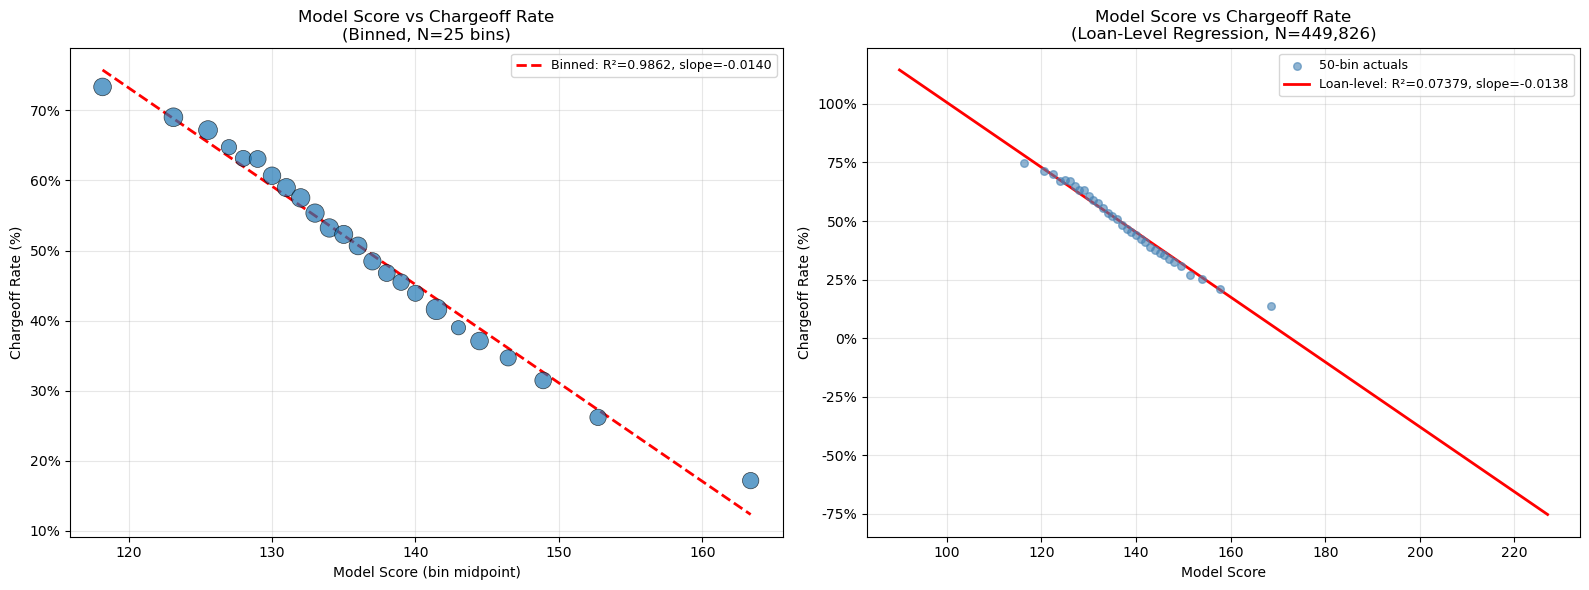


SUMMARY: Model Score to Chargeoff Rate Formula

  Recommended formula (linear):

    chargeoff_rate = 2.390758 -0.013846 * model_score

  Or equivalently:

    PD(ms) = 2.3908 - 0.0138 * ms

  Binned validation confirms the linear relationship (binned R² = 0.9862).



In [20]:
# =============================================================================
# CELL 15: MODEL SCORE vs CHARGEOFF RATE -- BINNED & UNBINNED FORMULAS
# =============================================================================

from scipy.stats import linregress as lr

# --- Unbinned (loan-level) regression: is_chargeoff ~ model_score ---
valid['is_chargeoff_int'] = valid['is_chargeoff'].astype(int)
slope_ub, intercept_ub, r_ub, p_ub, se_ub = lr(valid['model_score'], valid['is_chargeoff_int'])
r2_ub = r_ub ** 2

print("=" * 100)
print("MODEL SCORE vs CHARGEOFF RATE (UNIT LOSS)")
print("=" * 100)

print(f"""
  UNBINNED (Loan-Level) Linear Regression
  ----------------------------------------
    chargeoff_rate = {intercept_ub:.6f} + {slope_ub:.6f} * model_score

    Slope:     {slope_ub:+.6f}  (PD change per 1 model-score point)
    Intercept: {intercept_ub:+.6f}
    R²:        {r2_ub:.5f}
    p-value:   {p_ub:.2e}
    Std Error: {se_ub:.6f}
    N:         {len(valid):,}
""")

# --- Binned regression: 25 equal-frequency bins ---
N_CO_BINS = 25
valid['_co_bin'] = pd.qcut(valid['model_score'], q=N_CO_BINS, duplicates='drop')
co_binned = valid.groupby('_co_bin', observed=True).agg(
    ms_mid=('model_score', 'mean'),
    chargeoff_rate=('is_chargeoff_int', 'mean'),
    loan_count=('account_number', 'count'),
).reset_index()

slope_b, intercept_b, r_b, p_b, se_b = lr(co_binned['ms_mid'], co_binned['chargeoff_rate'])
r2_b = r_b ** 2

print(f"""  BINNED ({N_CO_BINS} equal-frequency bins) Linear Regression
  ----------------------------------------
    chargeoff_rate = {intercept_b:.6f} + {slope_b:.6f} * model_score

    Slope:     {slope_b:+.6f}  (PD change per 1 model-score point)
    Intercept: {intercept_b:+.6f}
    R²:        {r2_b:.5f}
    p-value:   {p_b:.2e}
    Std Error: {se_b:.6f}
    N (bins):  {len(co_binned)}
""")

# --- Binned data table ---
print(f"  {'Bin':>4}  {'MS Mid':>8}  {'Chargeoff Rate':>14}  {'N':>8}")
print(f"  {'-'*42}")
for i, row in co_binned.iterrows():
    print(f"  {i:>4}  {row['ms_mid']:>8.2f}  {row['chargeoff_rate']:>14.4f}  {row['loan_count']:>8,}")

# --- Comparison of binned vs unbinned ---
print(f"""
  COMPARISON
  ----------------------------------------
    {'':>20} {'Unbinned':>12}  {'Binned':>12}
    {'Slope':<20} {slope_ub:>+12.6f}  {slope_b:>+12.6f}
    {'Intercept':<20} {intercept_ub:>+12.6f}  {intercept_b:>+12.6f}
    {'R²':<20} {r2_ub:>12.5f}  {r2_b:>12.5f}

    Interpretation:
      Each +1 model-score point reduces chargeoff probability by ~{abs(slope_ub):.4f}
      ({abs(slope_ub)*100:.2f} percentage points).

      At model_score = 125:  PD = {intercept_ub + slope_ub * 125:.4f} ({(intercept_ub + slope_ub * 125)*100:.1f}%)
      At model_score = 140:  PD = {intercept_ub + slope_ub * 140:.4f} ({(intercept_ub + slope_ub * 140)*100:.1f}%)
      At model_score = 155:  PD = {intercept_ub + slope_ub * 155:.4f} ({(intercept_ub + slope_ub * 155)*100:.1f}%)
""")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Binned scatter + regression line
ax = axes[0]
ax.scatter(co_binned['ms_mid'], co_binned['chargeoff_rate'] * 100,
           s=co_binned['loan_count'] / co_binned['loan_count'].max() * 200 + 20,
           alpha=0.7, zorder=3, edgecolors='black', linewidth=0.5)
x_fit = np.linspace(co_binned['ms_mid'].min(), co_binned['ms_mid'].max(), 100)
ax.plot(x_fit, (intercept_b + slope_b * x_fit) * 100, 'r--', linewidth=2,
        label=f"Binned: R²={r2_b:.4f}, slope={slope_b:.4f}")
ax.set_xlabel('Model Score (bin midpoint)')
ax.set_ylabel('Chargeoff Rate (%)')
ax.set_title(f'Model Score vs Chargeoff Rate\n(Binned, N={N_CO_BINS} bins)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.grid(True, alpha=0.3)

# Panel 2: Unbinned -- use finer bins for visual clarity + overlay loan-level line
ax = axes[1]
N_VIS_BINS = 50
valid['_co_vis_bin'] = pd.qcut(valid['model_score'], q=N_VIS_BINS, duplicates='drop')
co_vis = valid.groupby('_co_vis_bin', observed=True).agg(
    ms_mid=('model_score', 'mean'),
    chargeoff_rate=('is_chargeoff_int', 'mean'),
    loan_count=('account_number', 'count'),
).reset_index()

ax.scatter(co_vis['ms_mid'], co_vis['chargeoff_rate'] * 100,
           s=30, alpha=0.6, zorder=3, color='steelblue', label='50-bin actuals')
x_fit2 = np.linspace(valid['model_score'].min(), valid['model_score'].max(), 100)
ax.plot(x_fit2, (intercept_ub + slope_ub * x_fit2) * 100, 'r-', linewidth=2,
        label=f"Loan-level: R²={r2_ub:.5f}, slope={slope_ub:.4f}")
ax.set_xlabel('Model Score')
ax.set_ylabel('Chargeoff Rate (%)')
ax.set_title(f'Model Score vs Chargeoff Rate\n(Loan-Level Regression, N={len(valid):,})')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_score_vs_chargeoff_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Cleanup temp columns
valid.drop(columns=['_co_bin', '_co_vis_bin', 'is_chargeoff_int'], inplace=True, errors='ignore')

print(f"""
{'=' * 100}
SUMMARY: Model Score to Chargeoff Rate Formula
{'=' * 100}

  Recommended formula (linear):

    chargeoff_rate = {intercept_ub:.6f} {slope_ub:+.6f} * model_score

  Or equivalently:

    PD(ms) = {intercept_ub:.4f} - {abs(slope_ub):.4f} * ms

  Binned validation confirms the linear relationship (binned R² = {r2_b:.4f}).
{'=' * 100}
""")